# E3 Observation-Process Misspecification

In [1]:
import importlib
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root containing src/.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS_ROOT = ROOT / "outputs"
print("Project root:", ROOT)
print("Outputs root:", OUTPUTS_ROOT)

import pandas as pd
from IPython.display import display

from src.config import setup_environment
from src.diagnostics import evaluate_curve_level_ppc, evaluate_curve_level_ppc_tau_aligned
from src.experiments import (
    build_E3_caselevel_correlation_summary,
    build_E3_controlled_cases,
    build_E3_eta_tau_bin_summaries,
    build_E3_severity_summary,
    build_E3_truth_region_tables,
    run_E3_evaluation,
    run_E3_example_case,
)
from src.plotting import (
    plot_E3_eta_bin_panels,
    plot_E3_severity_single_line,
    plot_E3_tau_bin_panels,
    plot_E3_true_R0_group_panels,
    plot_E3_true_beta_group_panels,
    plot_E3_true_gamma_group_panels,
    plot_curve_level_ppc_summary,
    plot_e3_controlled_grid,
    plot_e3_example_case,
    plot_e3_overall_figure,
    plot_feature_residuals,
    scatter_with_group_colors,
)
from src.simulators import simulate_case_E3, simulate_curve
from src.workflow import train_workflow


Project root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project
Outputs root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project/outputs


In [2]:
missing = []
for pkg in ["bayesflow", "tensorflow", "keras"]:
    try:
        importlib.import_module(pkg)
        print(f"[ok] {pkg}")
    except Exception as e:
        missing.append(pkg)
        print(f"[missing] {pkg}: {e}")

if missing:
    print("\nInstall missing packages in the current kernel environment, for example:")
    print("python -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn")
else:
    print("\nBackend check passed.")


INFO:bayesflow:Using backend 'tensorflow'


[ok] bayesflow
[ok] tensorflow
[ok] keras

Backend check passed.


In [3]:
# Optional install cell.
# Uncomment and run this cell if the backend packages are missing,
# then restart the kernel before re-running the notebook.

import sys
print(sys.executable)
# !{sys.executable} -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn


/opt/anaconda3/envs/bayesflow311/bin/python


In [4]:
setup_environment(seed=42)
workflow_E0, history_E0 = train_workflow(seed=42)


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


bayesflow: 2.0.7
tensorflow: 2.17.0
keras: 3.9.0
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.15.3
matplotlib: 3.8.4
Epoch 1/12
60/60 - 16s - 261ms/step - loss: 2.5441
Epoch 2/12
60/60 - 3s - 51ms/step - loss: 1.4825
Epoch 3/12
60/60 - 4s - 63ms/step - loss: 0.9436
Epoch 4/12
60/60 - 4s - 62ms/step - loss: 0.4041
Epoch 5/12
60/60 - 3s - 52ms/step - loss: 0.1514
Epoch 6/12
60/60 - 3s - 58ms/step - loss: -1.6706e-01
Epoch 7/12
60/60 - 7s - 109ms/step - loss: -4.1431e-01
Epoch 8/12
60/60 - 4s - 61ms/step - loss: -5.3902e-01
Epoch 9/12
60/60 - 3s - 55ms/step - loss: -7.0491e-01
Epoch 10/12
60/60 - 4s - 59ms/step - loss: -8.0065e-01
Epoch 11/12
60/60 - 3s - 54ms/step - loss: -8.9503e-01
Epoch 12/12
60/60 - 3s - 58ms/step - loss: -9.4798e-01


## Single-case sanity check

E3 studies misspecification in the observation process rather than in the latent epidemic dynamics. We first inspect a single illustrative case before moving to the full experiment.

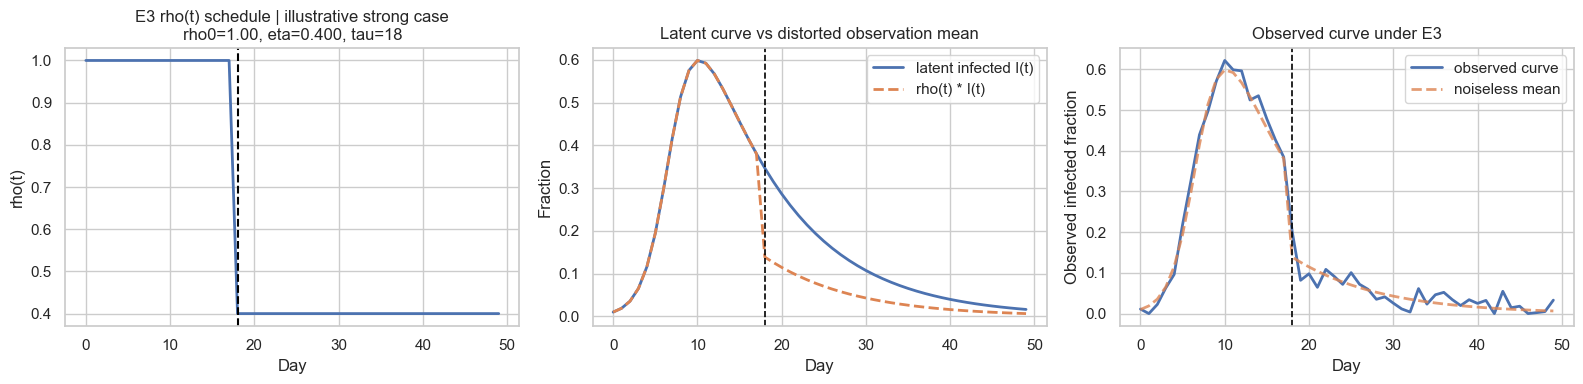

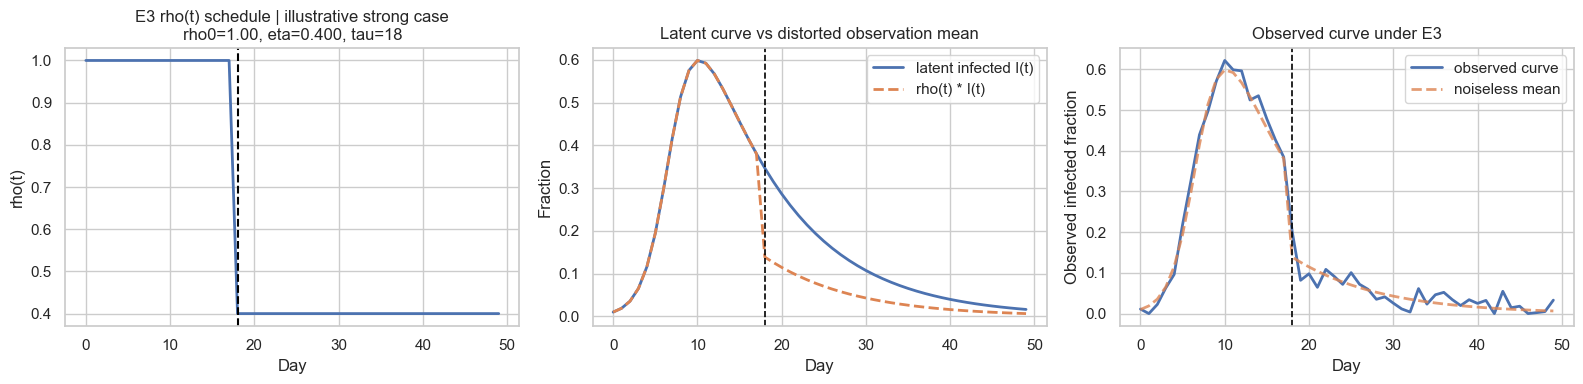

In [5]:
example_case_E3 = run_E3_example_case()
plot_e3_example_case(
    example_case_E3,
    out_path=str(OUTPUTS_ROOT / "E3" / "E3_example_case.png"),
)


In [6]:
# Controlled mild / medium / strong comparison
# Fix beta/gamma/tau and vary only eta by severity

print("Illustrative E3 case:")
print(f"  severity   : {example_case_E3['case']['severity']}")
print(f"  beta       : {example_case_E3['case']['true_beta']:.4f}")
print(f"  gamma      : {example_case_E3['case']['true_gamma']:.4f}")
print(f"  R0         : {example_case_E3['case']['true_R0']:.4f}")
print(f"  rho0       : {example_case_E3['case']['rho0']:.4f}")
print(f"  eta        : {example_case_E3['case']['eta']:.4f}")
print(f"  tau        : {example_case_E3['case']['tau']}")


Illustrative E3 case:
  severity   : strong
  beta       : 0.7500
  gamma      : 0.1000
  R0         : 7.5000
  rho0       : 1.0000
  eta        : 0.4000
  tau        : 18


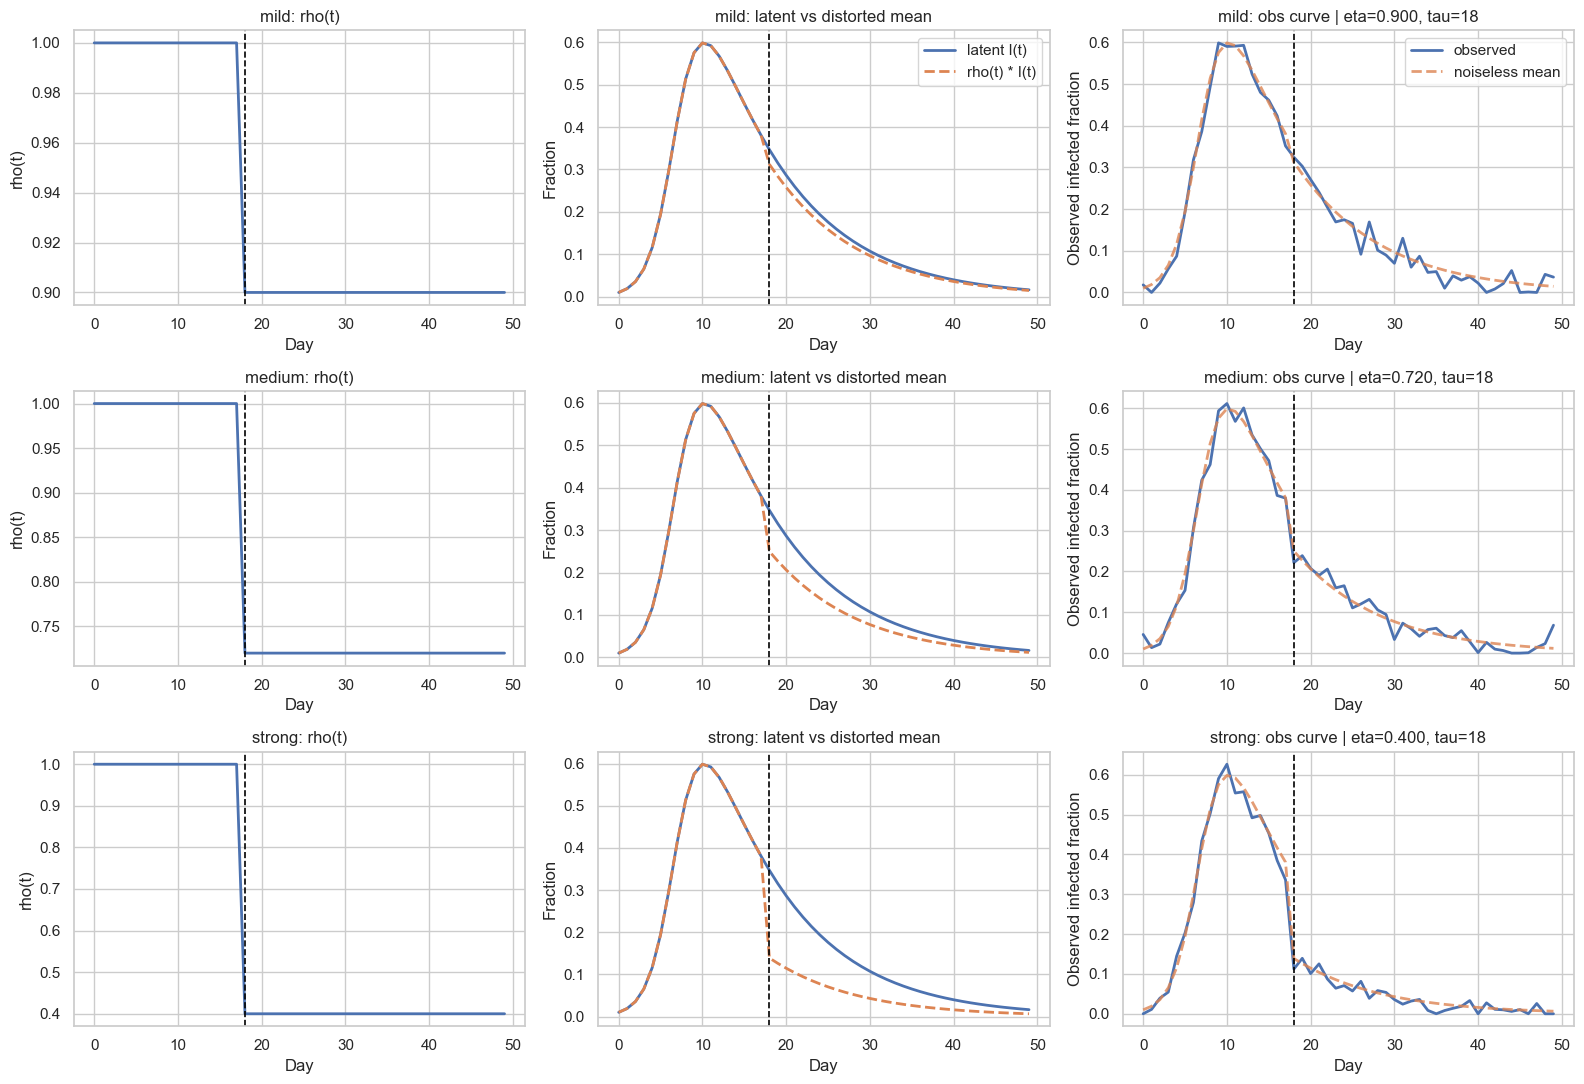

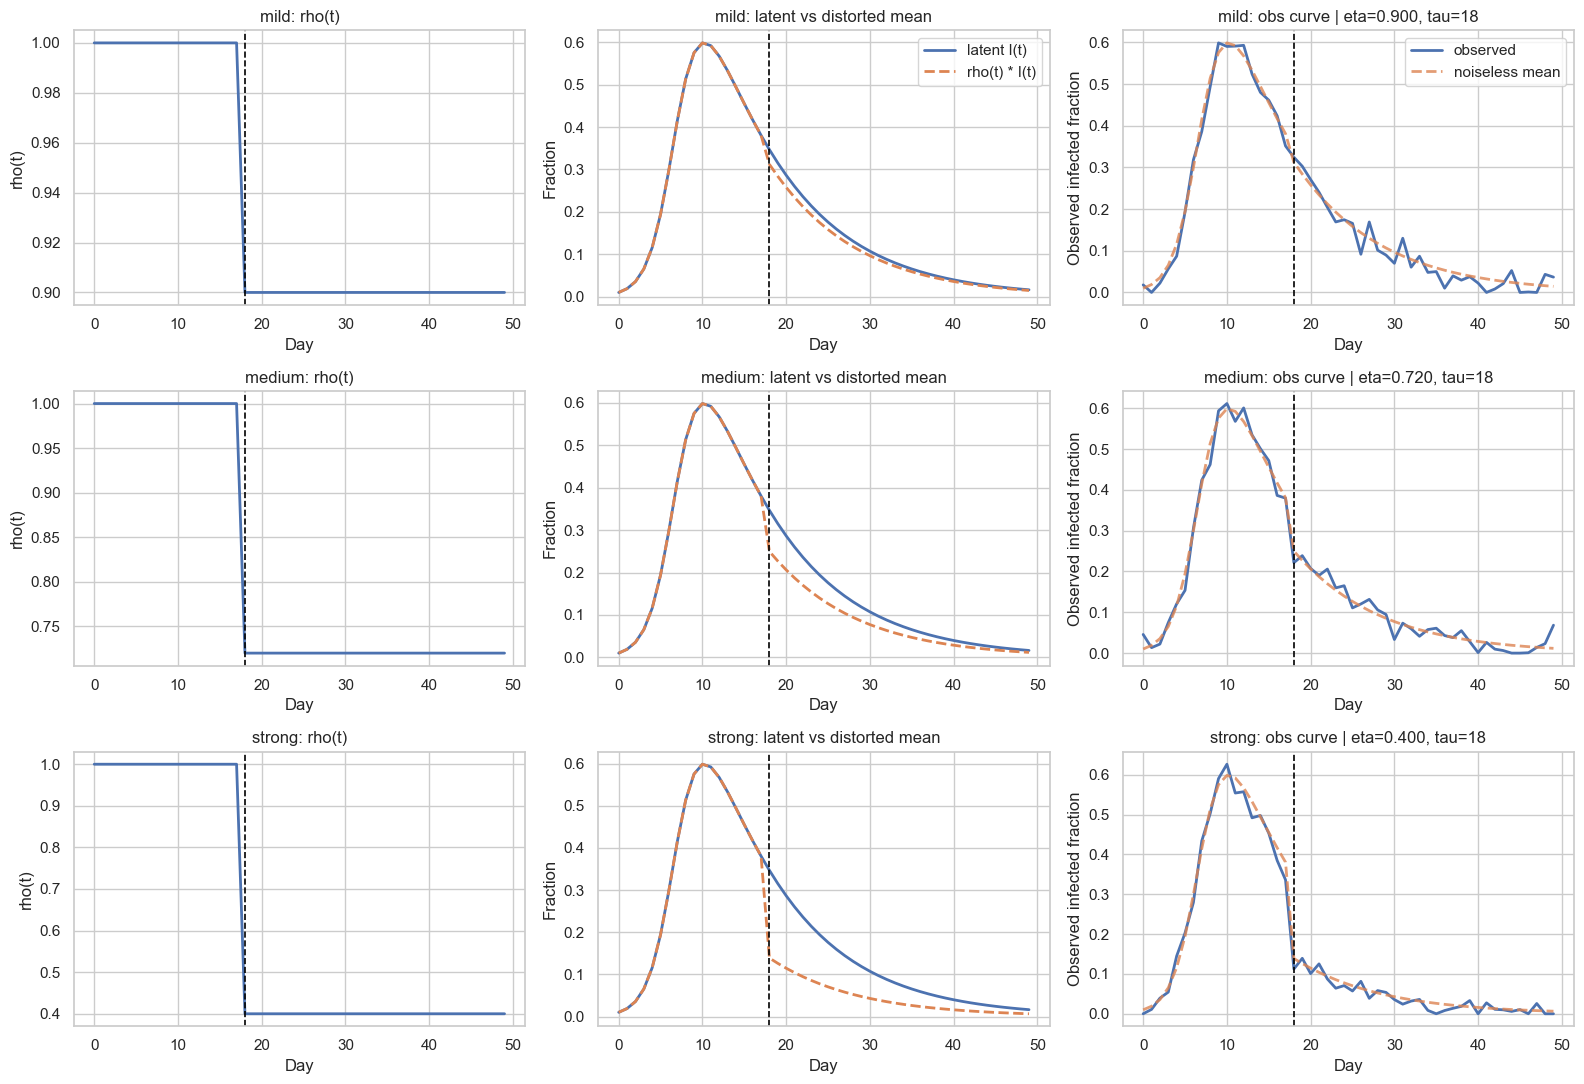

In [7]:
controlled_cases_E3 = build_E3_controlled_cases()
plot_e3_controlled_grid(
    controlled_cases_E3,
    out_path=str(OUTPUTS_ROOT / "E3" / "E3_controlled_severity_grid.png"),
)


In [8]:
severity_outputs_E3 = {}
for severity in ["mild", "medium", "strong"]:
    case_df_E3, recovery_df_E3, coverage_df_E3, feature_case_df_E3, feature_summary_df_E3 = run_E3_evaluation(
        workflow=workflow_E0,
        severity=severity,
        n_test=100,
        num_posterior_samples=2000,
        n_ppc_draws=100,
        seed=2028,
    )
    severity_outputs_E3[severity] = {
        "case_df": case_df_E3,
        "recovery_df": recovery_df_E3,
        "coverage_df": coverage_df_E3,
        "feature_case_df": feature_case_df_E3,
        "feature_summary_df": feature_summary_df_E3,
    }
    out_dir = OUTPUTS_ROOT / "E3" / severity
    out_dir.mkdir(parents=True, exist_ok=True)
    case_df_E3.to_csv(out_dir / "E3_case_level.csv", index=False)
    recovery_df_E3.to_csv(out_dir / "E3_recovery_summary.csv", index=False)
    coverage_df_E3.to_csv(out_dir / "E3_coverage_summary.csv", index=False)
    feature_case_df_E3.to_csv(out_dir / "E3_ppc_feature_case_level.csv", index=False)
    feature_summary_df_E3.to_csv(out_dir / "E3_ppc_feature_summary.csv", index=False)


In [9]:
display(severity_outputs_E3["mild"]["case_df"].head())
display(severity_outputs_E3["mild"]["recovery_df"].round(4))
display(severity_outputs_E3["mild"]["coverage_df"].round(4))
display(severity_outputs_E3["mild"]["feature_summary_df"].round(4))


,case_id,true_beta,true_gamma,true_R0,rho0,tau,eta,severity,beta_mean,beta_median,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.448077,0.316651,1.415052,1.0,14,0.997739,mild,0.449942,0.448686,...,0.006202,0.005103,0.005103,0.000026,1.0,1.0,-0.014906,-0.022381,0.022381,0.000501
1,1,0.865699,0.377376,2.293997,1.0,25,0.933624,mild,0.862201,0.866124,...,0.013584,0.012577,0.012577,0.000158,0.0,1.0,-0.086682,-0.089584,0.089584,0.008025
2,2,0.130403,0.316478,0.412045,1.0,13,0.862665,mild,0.206815,0.185790,...,0.004154,0.017977,0.017977,0.000323,0.0,1.0,0.268668,0.246473,0.246473,0.060749
3,3,0.522899,0.184464,2.834688,1.0,24,0.870251,mild,0.529435,0.529301,...,0.013743,0.013565,0.013565,0.000184,0.0,0.0,-0.161610,-0.164032,0.164032,0.026907
4,4,0.258551,0.209109,1.236443,1.0,21,0.911207,mild,0.300203,0.296424,...,0.091669,0.094618,0.094618,0.008953,0.0,1.0,-0.210595,-0.206040,0.206040,0.042453


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.0036,0.0030,0.0340,0.0535,0.9775,0.0521
1,gamma,0.0039,0.0079,0.0293,0.0532,0.9176,0.0359
2,R0,-0.1114,-0.1145,0.1990,0.3037,0.9968,0.2317


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.63,0.13,0.9,0.96,0.06,0.0719,0.1683
1,gamma,0.5,0.42,-0.08,0.9,0.83,-0.07,0.0508,0.1166
2,R0,0.5,0.37,-0.13,0.9,0.88,-0.02,0.3056,0.7530


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.64,0.14,0.9,0.95,0.05,-0.6371,-1.0000,4.8900,8.4478,6.2482,9.7625,19.3770
1,peak_height,0.5,0.63,0.13,0.9,0.97,0.07,-0.0037,-0.0049,0.0111,0.0144,0.0178,0.0231,0.0561
2,cumulative_infected,0.5,0.75,0.25,0.9,1.00,0.10,-0.0325,-0.0574,0.1094,0.1503,0.3111,0.3818,0.9617
3,early_growth_slope,0.5,0.50,0.00,0.9,0.95,0.05,-0.0009,-0.0008,0.0023,0.0028,0.0034,0.0045,0.0109


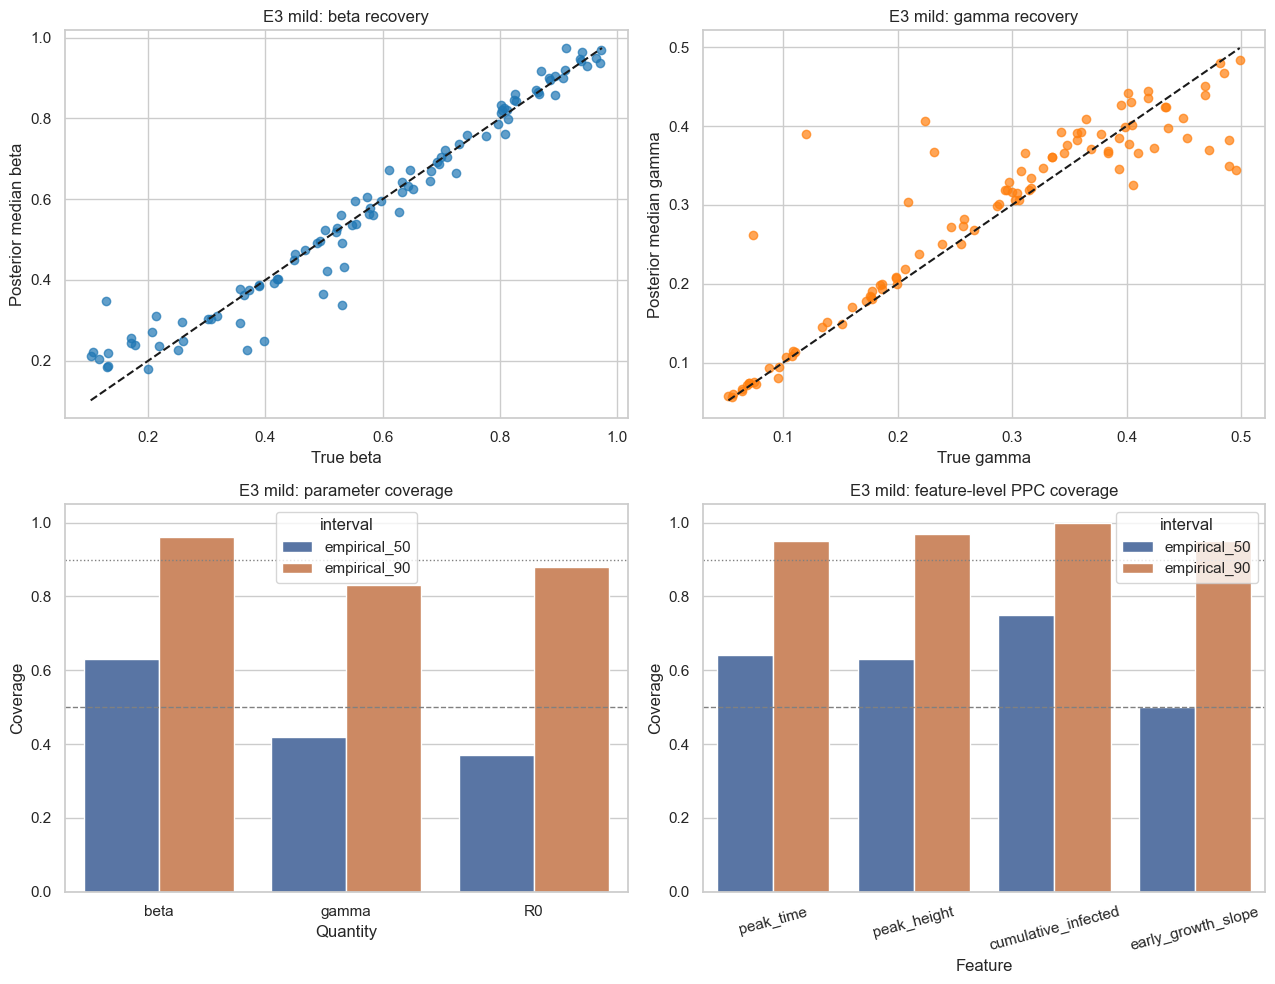

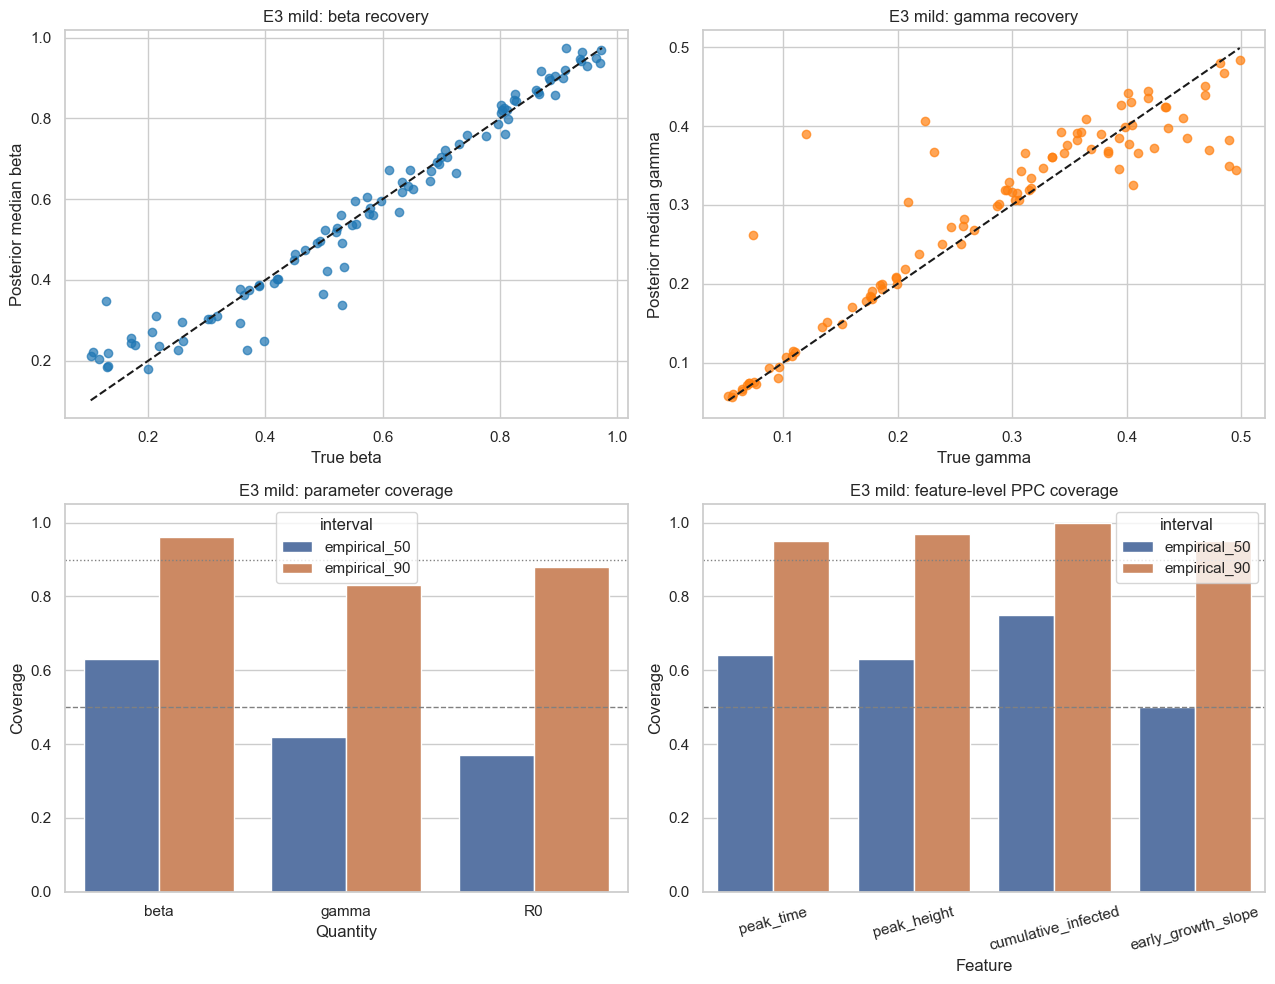

In [10]:
plot_e3_overall_figure(
    severity_outputs_E3["mild"]["case_df"],
    severity_outputs_E3["mild"]["coverage_df"],
    severity_outputs_E3["mild"]["feature_summary_df"],
    severity_label="mild",
    out_path=str(OUTPUTS_ROOT / "E3" / "mild" / "E3_overall_figure.png"),
)


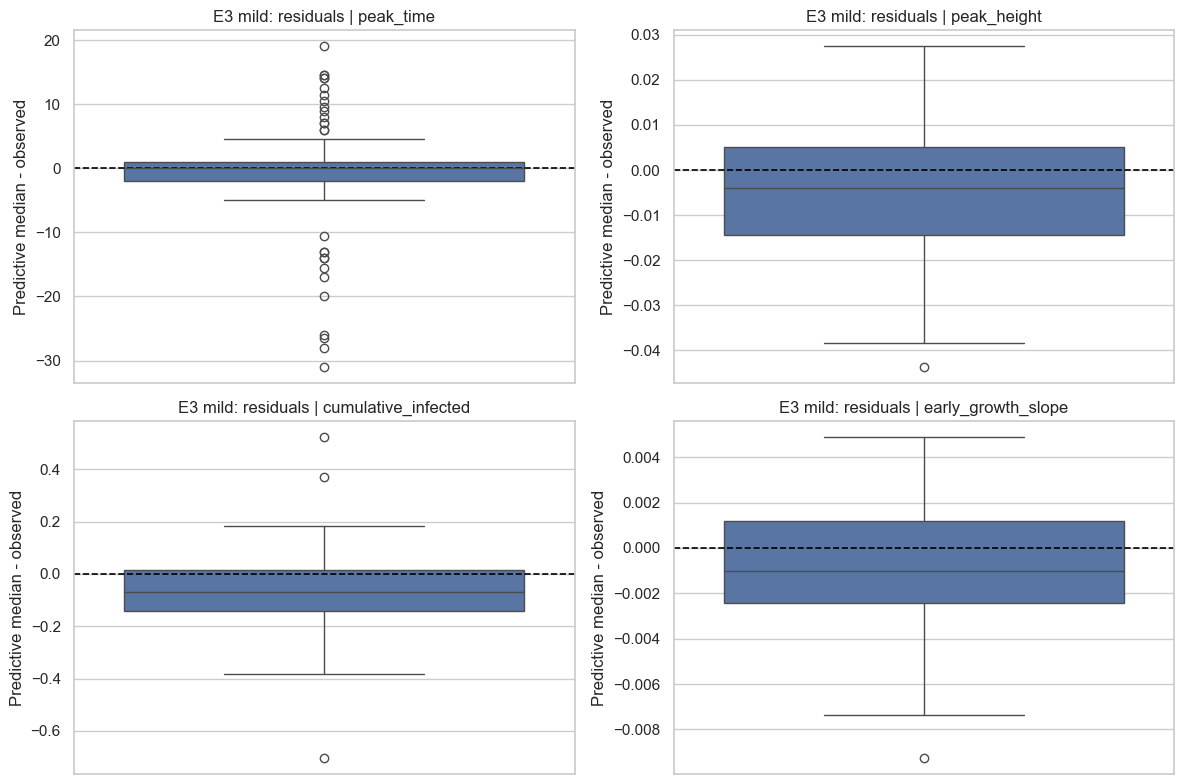

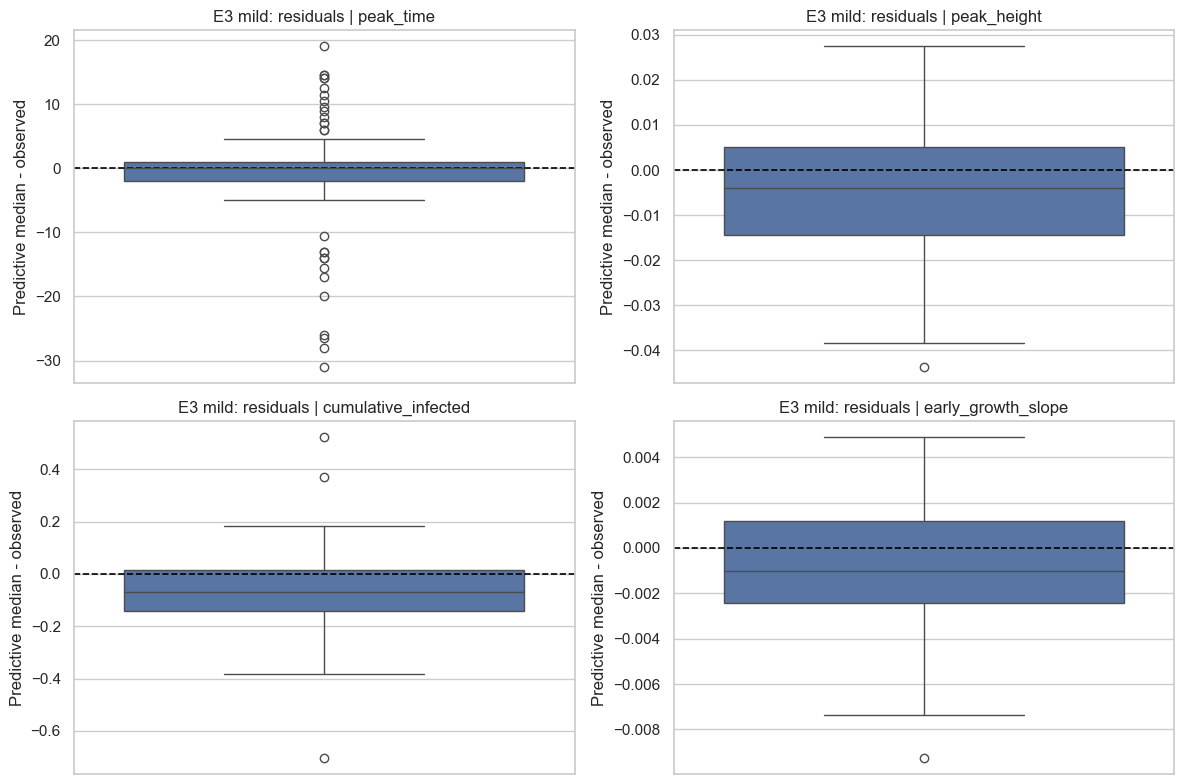

In [11]:
plot_feature_residuals(
    severity_outputs_E3["mild"]["feature_case_df"],
    title_prefix="E3 mild",
)


In [12]:
display(severity_outputs_E3["medium"]["case_df"].head())
display(severity_outputs_E3["medium"]["recovery_df"].round(4))
display(severity_outputs_E3["medium"]["coverage_df"].round(4))
display(severity_outputs_E3["medium"]["feature_summary_df"].round(4))


,case_id,true_beta,true_gamma,true_R0,rho0,tau,eta,severity,beta_mean,beta_median,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.448077,0.316651,1.415052,1.0,14,0.846232,medium,0.456606,0.456870,...,0.028891,0.030384,0.030384,0.000923,0.0,1.0,-0.087250,-0.091199,0.091199,0.008317
1,1,0.865699,0.377376,2.293997,1.0,25,0.739373,medium,0.864763,0.869638,...,0.014274,0.012924,0.012924,0.000167,0.0,1.0,-0.083939,-0.087970,0.087970,0.007739
2,2,0.130403,0.316478,0.412045,1.0,13,0.621108,medium,0.208071,0.184542,...,0.002978,0.016072,0.016072,0.000258,0.0,1.0,0.274010,0.252302,0.252302,0.063656
3,3,0.522899,0.184464,2.834688,1.0,24,0.633752,medium,0.547199,0.547297,...,0.025661,0.025227,0.025227,0.000636,0.0,0.0,-0.228534,-0.231765,0.231765,0.053715
4,4,0.258551,0.209109,1.236443,1.0,21,0.702011,medium,0.302846,0.296848,...,0.107476,0.114767,0.114767,0.013171,0.0,1.0,-0.256732,-0.256150,0.256150,0.065613


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.0154,0.0149,0.0424,0.0593,0.9740,0.0544
1,gamma,0.0145,0.0190,0.0391,0.0598,0.9038,0.0372
2,R0,-0.2538,-0.2584,0.3288,0.5484,0.9942,0.2208


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.51,0.01,0.9,0.86,-0.04,0.0751,0.1754
1,gamma,0.5,0.30,-0.20,0.9,0.57,-0.33,0.0520,0.1205
2,R0,0.5,0.23,-0.27,0.9,0.68,-0.22,0.2888,0.7106


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.64,0.14,0.9,0.94,0.04,-0.4941,-0.9150,5.0150,8.5283,6.3996,10.0175,19.6090
1,peak_height,0.5,0.54,0.04,0.9,0.89,-0.01,-0.0076,-0.0088,0.0146,0.0200,0.0183,0.0232,0.0560
2,cumulative_infected,0.5,0.77,0.27,0.9,1.00,0.10,-0.0272,-0.0532,0.1206,0.1698,0.3143,0.3685,0.9198
3,early_growth_slope,0.5,0.53,0.03,0.9,0.94,0.04,-0.0008,-0.0007,0.0023,0.0028,0.0035,0.0044,0.0108


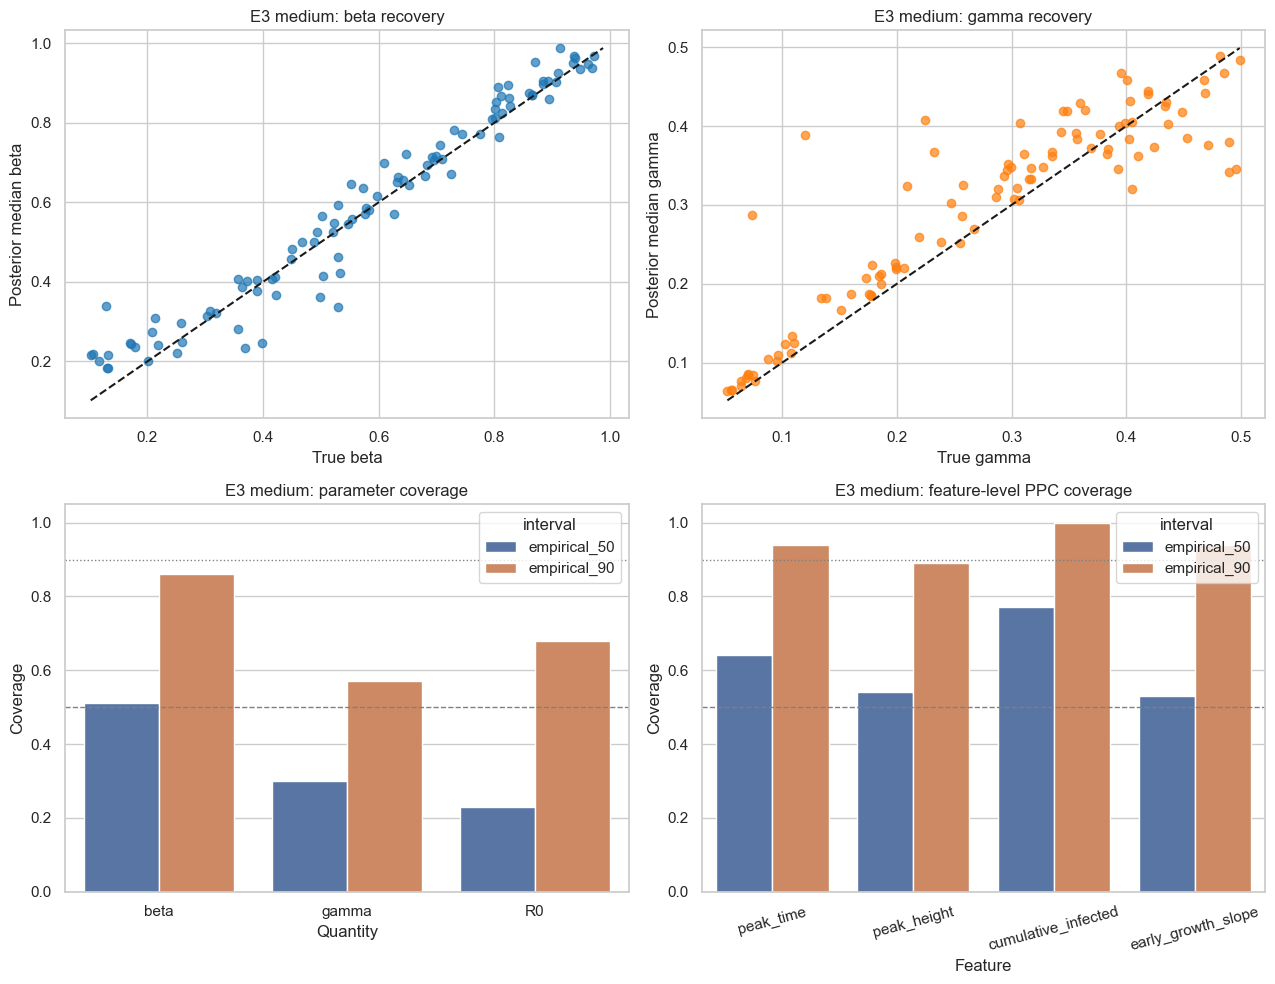

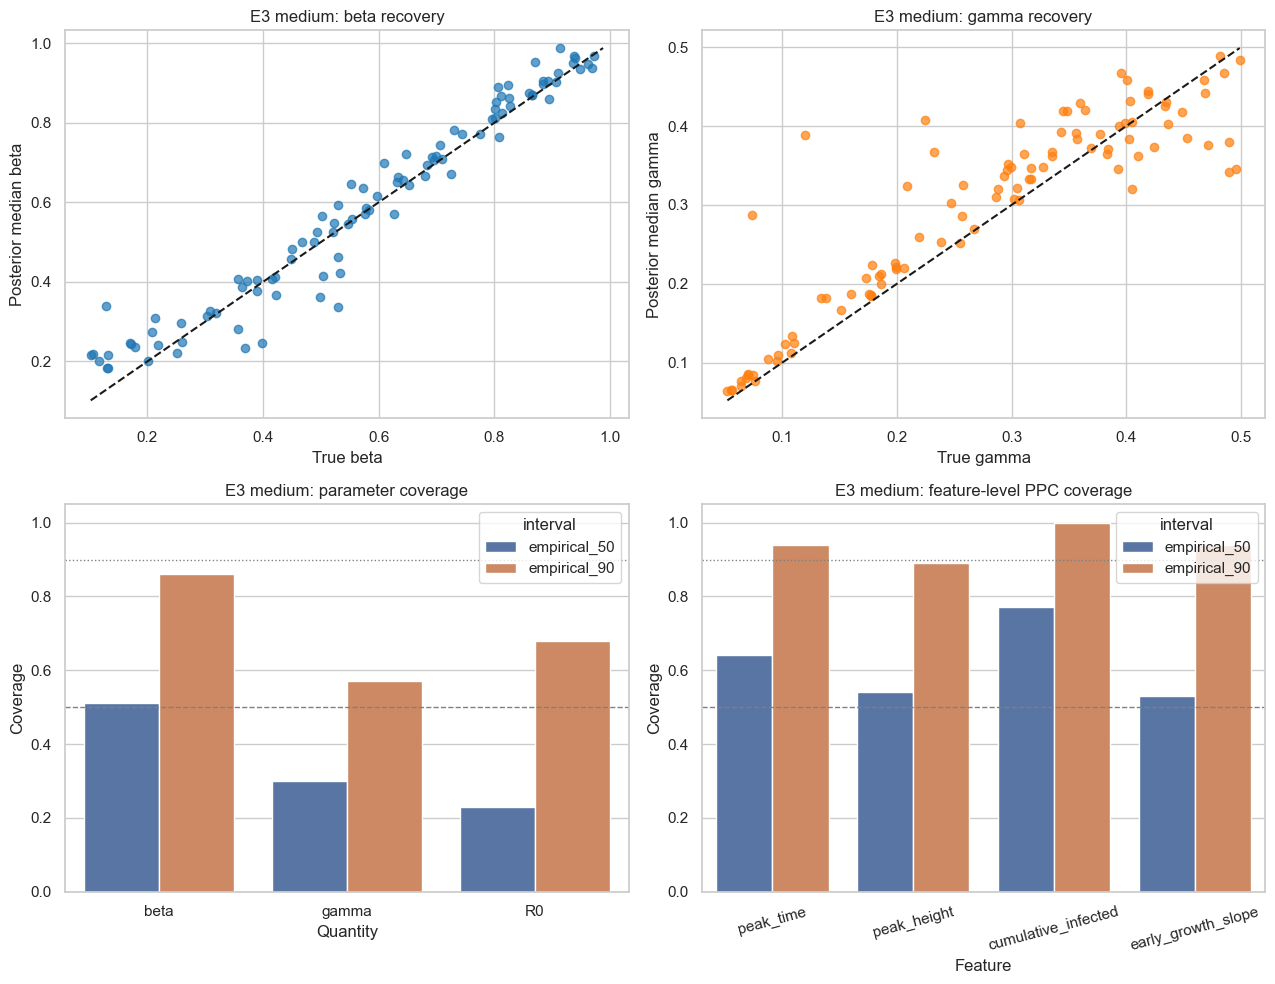

In [13]:
plot_e3_overall_figure(
    severity_outputs_E3["medium"]["case_df"],
    severity_outputs_E3["medium"]["coverage_df"],
    severity_outputs_E3["medium"]["feature_summary_df"],
    severity_label="medium",
    out_path=str(OUTPUTS_ROOT / "E3" / "medium" / "E3_overall_figure.png"),
)


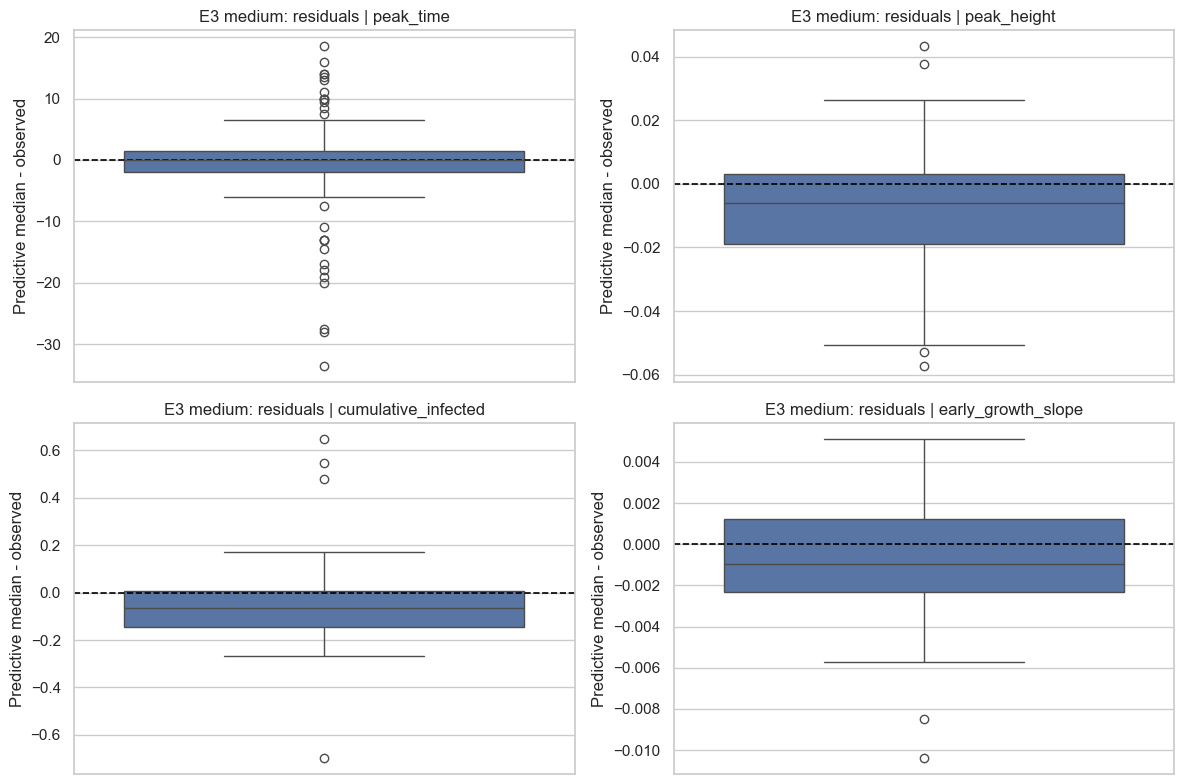

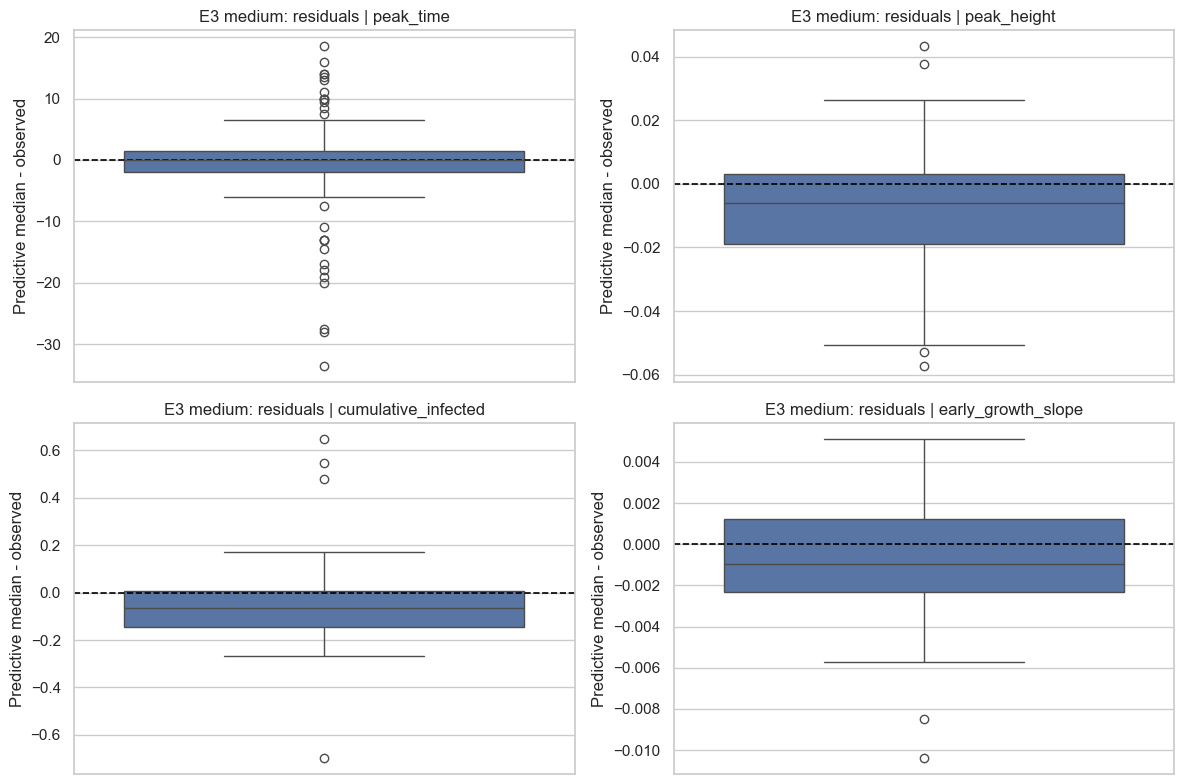

In [14]:
plot_feature_residuals(
    severity_outputs_E3["medium"]["feature_case_df"],
    title_prefix="E3 medium",
)


In [15]:
display(severity_outputs_E3["strong"]["case_df"].head())
display(severity_outputs_E3["strong"]["recovery_df"].round(4))
display(severity_outputs_E3["strong"]["coverage_df"].round(4))
display(severity_outputs_E3["strong"]["feature_summary_df"].round(4))


,case_id,true_beta,true_gamma,true_R0,rho0,tau,eta,severity,beta_mean,beta_median,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.448077,0.316651,1.415052,1.0,14,0.595478,strong,0.451579,0.452941,...,0.054336,0.058921,0.058921,0.003472,0.0,1.0,-0.192098,-0.180449,0.180449,0.032562
1,1,0.865699,0.377376,2.293997,1.0,25,0.467248,strong,0.865695,0.870485,...,0.014799,0.013912,0.013912,0.000194,0.0,1.0,-0.084467,-0.086545,0.086545,0.007490
2,2,0.130403,0.316478,0.412045,1.0,13,0.325329,strong,0.205611,0.186059,...,0.001635,0.013566,0.013566,0.000184,0.0,1.0,0.273072,0.252827,0.252827,0.063922
3,3,0.522899,0.184464,2.834688,1.0,24,0.340502,strong,0.568372,0.568702,...,0.040130,0.039581,0.039581,0.001567,0.0,0.0,-0.302256,-0.302980,0.302980,0.091797
4,4,0.258551,0.209109,1.236443,1.0,21,0.422414,strong,0.310344,0.306286,...,0.131788,0.142418,0.142418,0.020283,0.0,1.0,-0.308799,-0.291915,0.291915,0.085215


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.0337,0.0339,0.0636,0.0786,0.9612,0.0580
1,gamma,0.0316,0.0370,0.0558,0.0758,0.8665,0.0393
2,R0,-0.4637,-0.4671,0.5379,0.9643,0.9821,0.2132


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.31,-0.19,0.9,0.66,-0.24,0.0790,0.1856
1,gamma,0.5,0.25,-0.25,0.9,0.48,-0.42,0.0545,0.1257
2,R0,0.5,0.17,-0.33,0.9,0.57,-0.33,0.2611,0.6509


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.63,0.13,0.9,0.94,0.04,-0.3037,-0.9400,5.2300,8.4386,6.6217,10.2675,20.5175
1,peak_height,0.5,0.51,0.01,0.9,0.78,-0.12,-0.0156,-0.0169,0.0212,0.0327,0.0188,0.0227,0.0570
2,cumulative_infected,0.5,0.73,0.23,0.9,0.97,0.07,-0.0325,-0.0711,0.1530,0.2385,0.3164,0.3409,0.8830
3,early_growth_slope,0.5,0.49,-0.01,0.9,0.95,0.05,-0.0008,-0.0008,0.0024,0.0035,0.0036,0.0044,0.0109


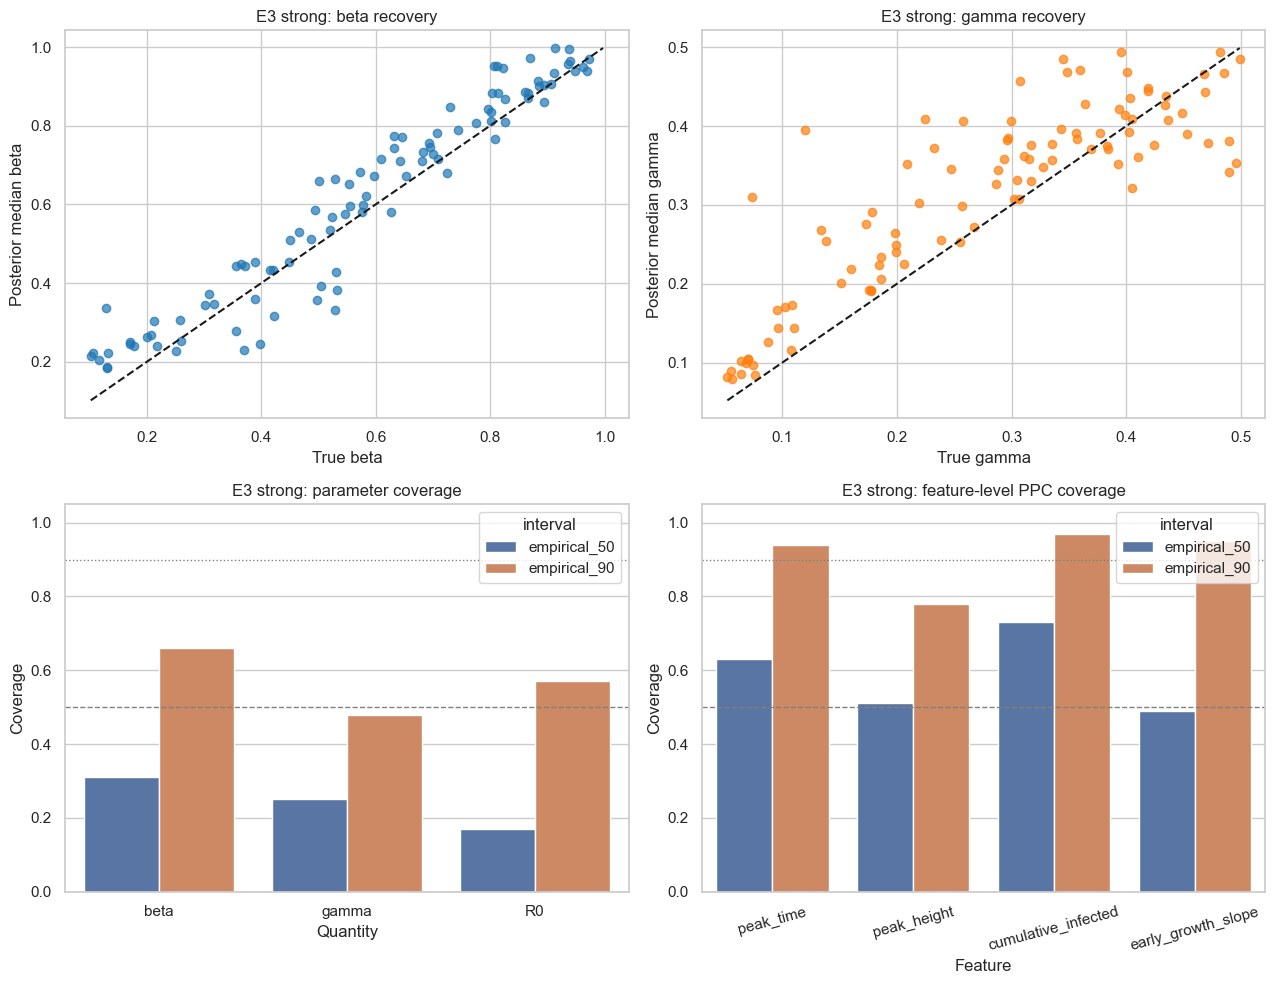

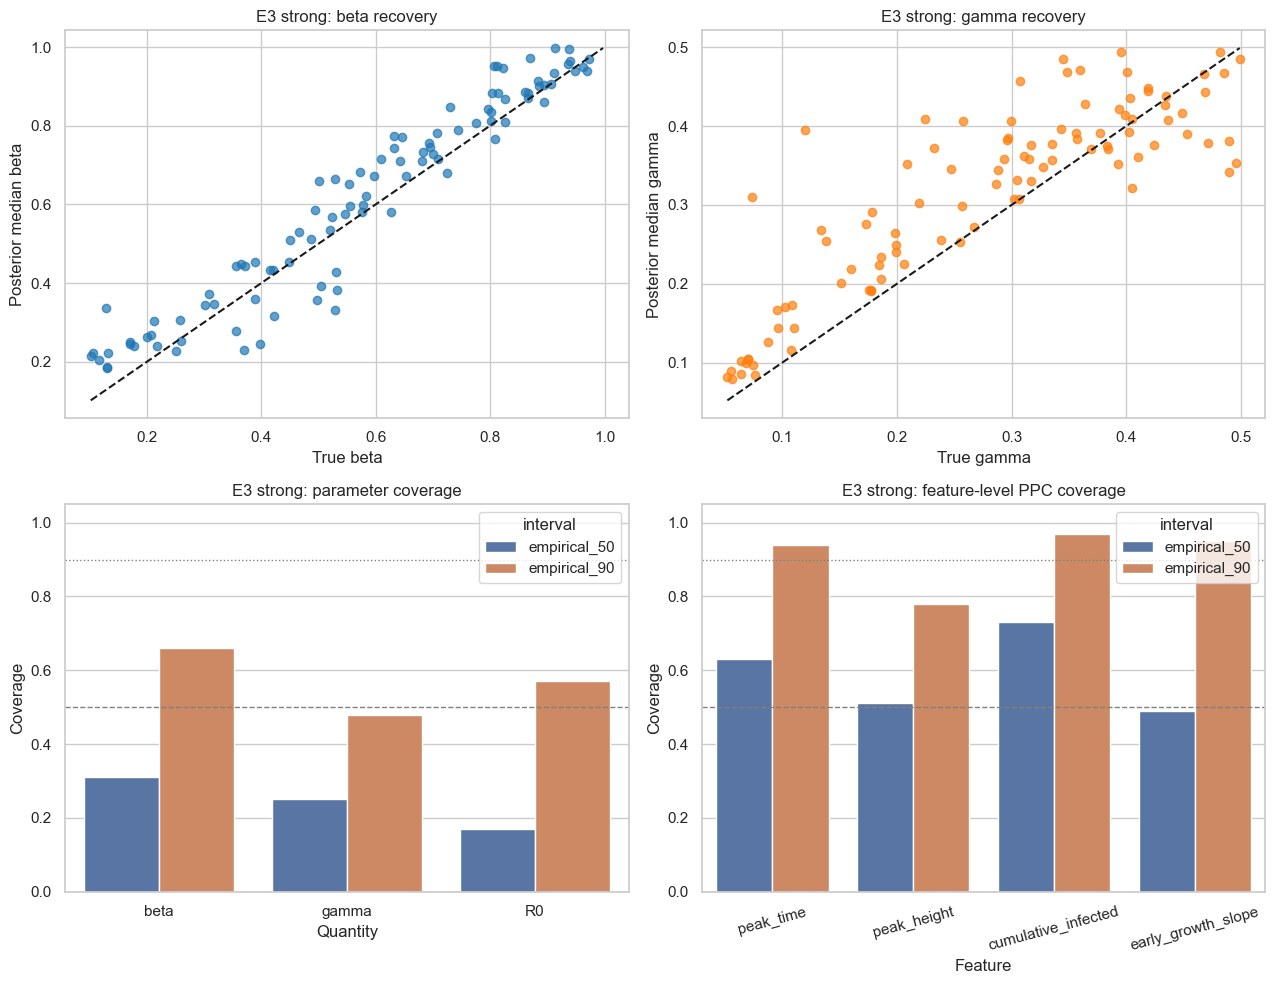

In [16]:
# severity-level aggregation

plot_e3_overall_figure(
    severity_outputs_E3["strong"]["case_df"],
    severity_outputs_E3["strong"]["coverage_df"],
    severity_outputs_E3["strong"]["feature_summary_df"],
    severity_label="strong",
    out_path=str(OUTPUTS_ROOT / "E3" / "strong" / "E3_overall_figure.png"),
)


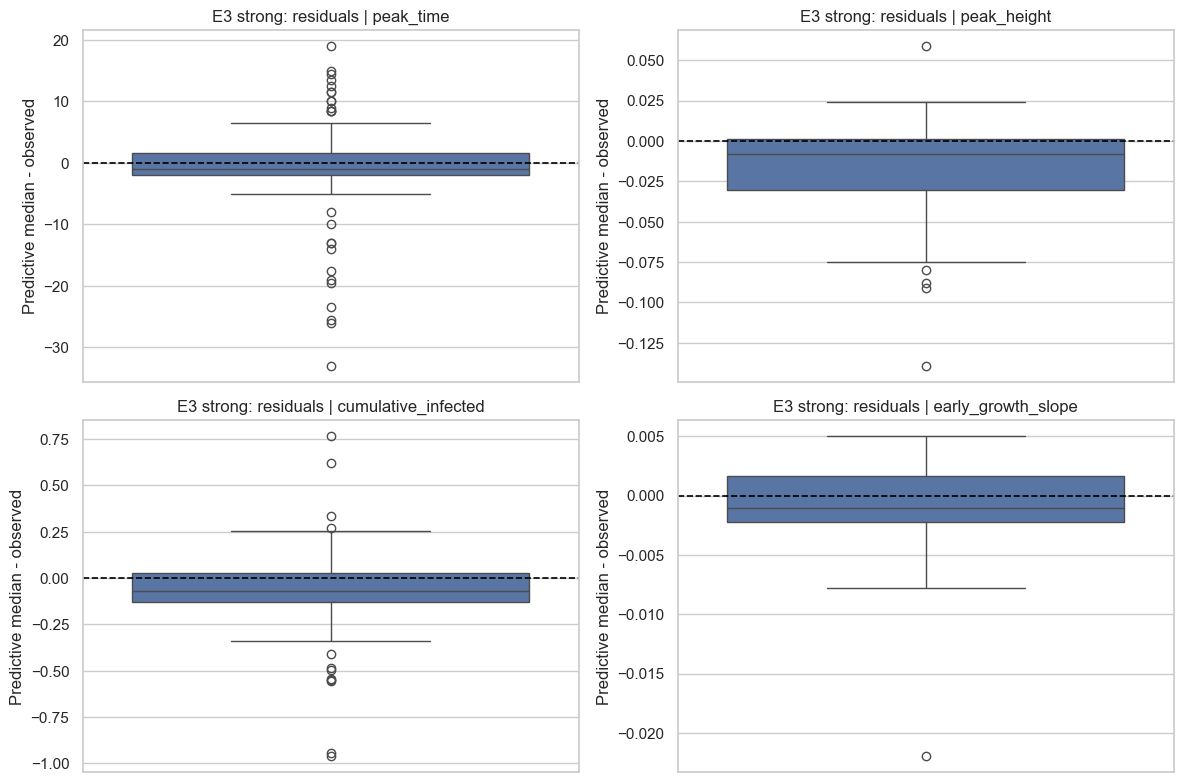

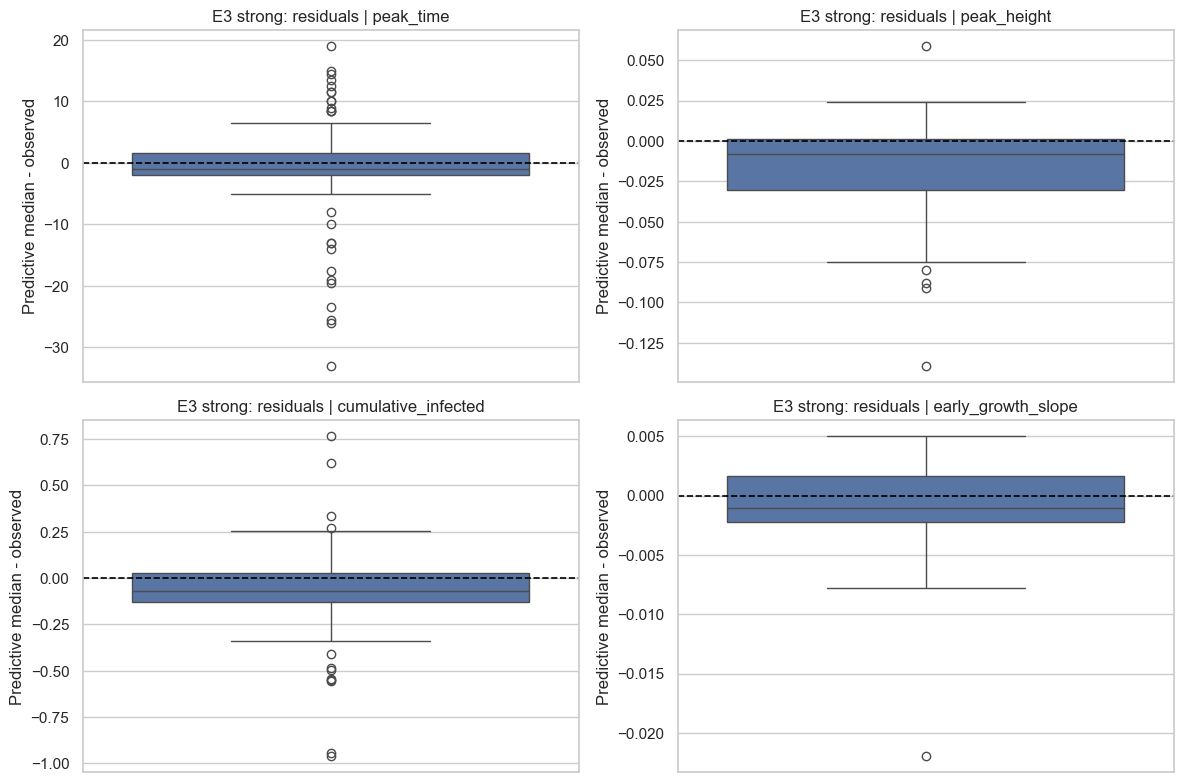

In [17]:
plot_feature_residuals(
    severity_outputs_E3["strong"]["feature_case_df"],
    title_prefix="E3 strong",
)


In [18]:
E3_severity_summary_df = build_E3_severity_summary(
    mild_recovery_df_E3=severity_outputs_E3["mild"]["recovery_df"],
    mild_coverage_df_E3=severity_outputs_E3["mild"]["coverage_df"],
    mild_feature_summary_df_E3=severity_outputs_E3["mild"]["feature_summary_df"],
    medium_recovery_df_E3=severity_outputs_E3["medium"]["recovery_df"],
    medium_coverage_df_E3=severity_outputs_E3["medium"]["coverage_df"],
    medium_feature_summary_df_E3=severity_outputs_E3["medium"]["feature_summary_df"],
    strong_recovery_df_E3=severity_outputs_E3["strong"]["recovery_df"],
    strong_coverage_df_E3=severity_outputs_E3["strong"]["coverage_df"],
    strong_feature_summary_df_E3=severity_outputs_E3["strong"]["feature_summary_df"],
)
severity_dir_E3 = OUTPUTS_ROOT / "E3" / "severity_summary"
severity_dir_E3.mkdir(parents=True, exist_ok=True)
E3_severity_summary_df.to_csv(severity_dir_E3 / "E3_severity_summary.csv", index=False)
display(E3_severity_summary_df.round(4))


,severity,beta_bias_median,gamma_bias_median,R0_bias_median,beta_empirical_90,gamma_empirical_90,R0_empirical_90,peak_height_empirical_90,cumulative_infected_empirical_90,early_growth_slope_empirical_90
0,mild,0.0030,0.0079,-0.1145,0.96,0.83,0.88,0.97,1.00,0.95
1,medium,0.0149,0.0190,-0.2584,0.86,0.57,0.68,0.89,1.00,0.94
2,strong,0.0339,0.0370,-0.4671,0.66,0.48,0.57,0.78,0.97,0.95


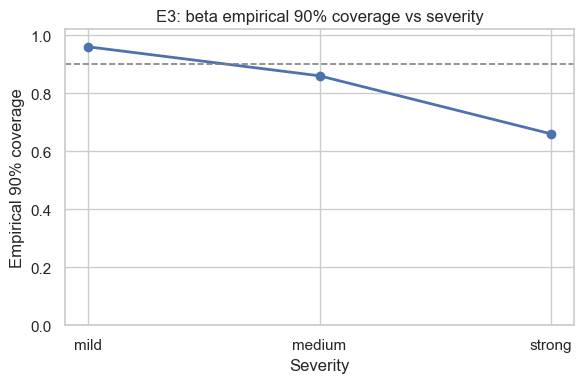

In [19]:
plot_E3_severity_single_line(
    E3_severity_summary_df,
    metric="beta_empirical_90",
    out_path=str(OUTPUTS_ROOT / "E3" / "severity_summary" / "E3_beta_empirical90_vs_severity.png"),
)


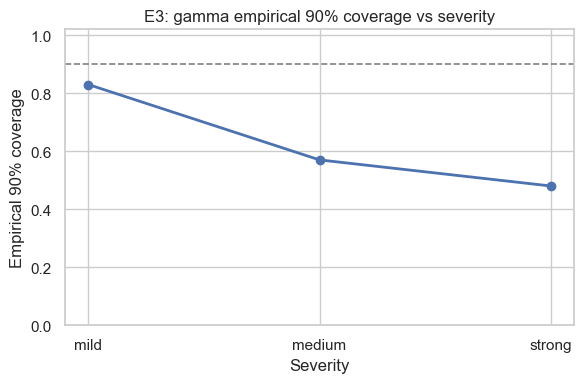

In [20]:
plot_E3_severity_single_line(
    E3_severity_summary_df,
    metric="gamma_empirical_90",
    out_path=str(OUTPUTS_ROOT / "E3" / "severity_summary" / "E3_gamma_empirical90_vs_severity.png"),
)


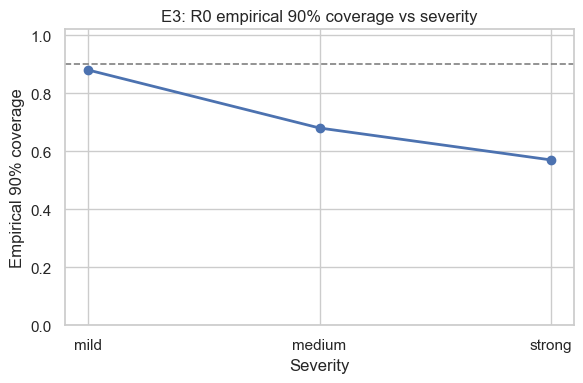

In [21]:
# curve-level PPC for all severities

plot_E3_severity_single_line(
    E3_severity_summary_df,
    metric="R0_empirical_90",
    out_path=str(OUTPUTS_ROOT / "E3" / "severity_summary" / "E3_R0_empirical90_vs_severity.png"),
)


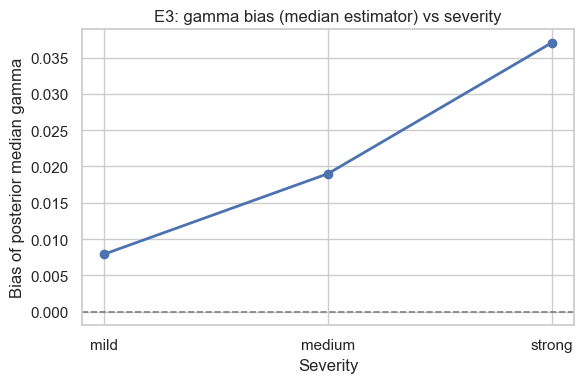

In [22]:
plot_E3_severity_single_line(
    E3_severity_summary_df,
    metric="gamma_bias_median",
    out_path=str(OUTPUTS_ROOT / "E3" / "severity_summary" / "E3_gamma_bias_median_vs_severity.png"),
)


In [23]:
curve_outputs_E3 = {}
for sev in ["mild", "medium", "strong"]:
    curve_case_df, curve_summary_df = evaluate_curve_level_ppc(
        workflow=workflow_E0,
        case_simulator=lambda rng=None, s=sev: simulate_case_E3(rng=rng, severity=s),
        predictive_curve_simulator=simulate_curve,
        n_test=100,
        num_posterior_samples=1000,
        n_ppc_draws=100,
        seed=2030,
        split_mode="fraction",
        split_frac=0.5,
    )
    curve_outputs_E3[sev] = {
        "case_df": curve_case_df,
        "summary_df": curve_summary_df,
    }
    out_dir = OUTPUTS_ROOT / "E3" / "curve_level" / sev
    out_dir.mkdir(parents=True, exist_ok=True)
    curve_case_df.to_csv(out_dir / f"E3_curve_case_level_{sev}.csv", index=False)
    curve_summary_df.to_csv(out_dir / f"E3_curve_summary_{sev}.csv", index=False)


In [24]:
display(curve_outputs_E3["mild"]["summary_df"].round(4))
display(curve_outputs_E3["mild"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6264,0.0952,0.6200,0.4800,0.7600
1,pointwise_empirical_90,0.9422,0.0320,0.9400,0.8800,0.9810
2,curve_bias_full,-0.0042,0.0037,-0.0048,-0.0093,0.0034
3,curve_mae_full,0.0139,0.0033,0.0136,0.0092,0.0195
4,curve_rmse_full,0.0183,0.0035,0.0179,0.0136,0.0241
5,curve_bias_first,-0.0045,0.0055,-0.0050,-0.0109,0.0019
6,curve_mae_first,0.0159,0.0040,0.0160,0.0100,0.0220
7,curve_rmse_first,0.0198,0.0045,0.0196,0.0140,0.0283
8,curve_bias_second,-0.0038,0.0056,-0.0049,-0.0102,0.0079
9,curve_mae_second,0.0119,0.0042,0.0115,0.0065,0.0198


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,second_minus_first_mae,split_mode,split_idx,true_beta,true_gamma,true_R0,rho0,tau,eta,severity
0,0,0.68,0.92,-0.0070,0.0142,0.0189,-0.0097,0.0183,0.0231,-0.0043,...,-0.0082,fraction,25,0.4567,0.4127,1.1065,1.0,10,0.9060,mild
1,1,0.54,0.94,-0.0121,0.0163,0.0216,-0.0088,0.0126,0.0167,-0.0155,...,0.0075,fraction,25,0.1830,0.1452,1.2602,1.0,22,0.8688,mild
2,2,0.66,0.92,-0.0046,0.0136,0.0179,0.0005,0.0142,0.0180,-0.0097,...,-0.0011,fraction,25,0.8345,0.4220,1.9774,1.0,21,0.8995,mild
3,3,0.56,1.00,-0.0019,0.0125,0.0162,0.0016,0.0164,0.0197,-0.0055,...,-0.0078,fraction,25,0.8501,0.4584,1.8547,1.0,23,0.9124,mild
4,4,0.76,1.00,-0.0053,0.0104,0.0144,-0.0051,0.0129,0.0168,-0.0055,...,-0.0051,fraction,25,0.8313,0.2983,2.7868,1.0,23,0.9550,mild


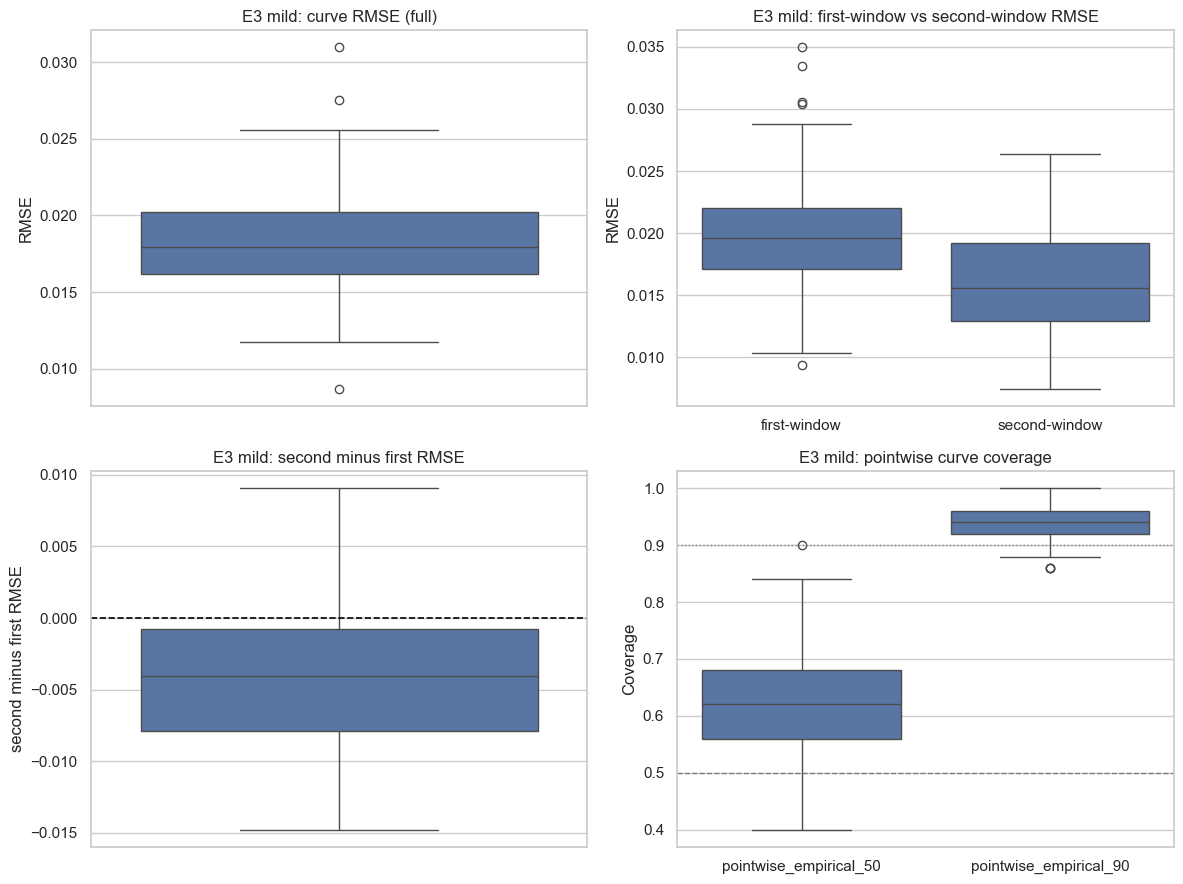

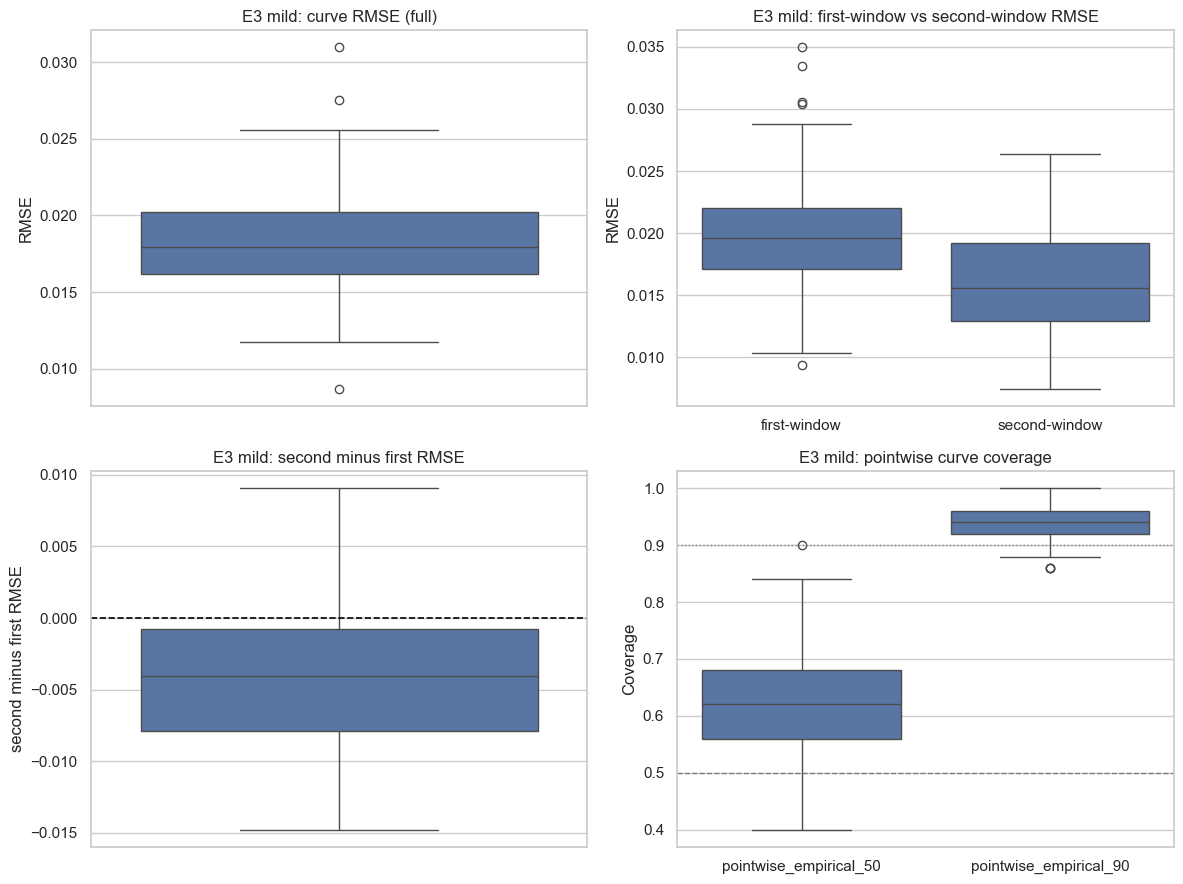

In [25]:
plot_curve_level_ppc_summary(
    curve_outputs_E3["mild"]["case_df"],
    severity_label="mild",
    experiment_label="E3",
    out_dir=str(OUTPUTS_ROOT / "E3" / "curve_level" / "mild"),
    split_mode="fraction",
)


In [26]:
display(curve_outputs_E3["medium"]["summary_df"].round(4))
display(curve_outputs_E3["medium"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6034,0.1203,0.6000,0.3790,0.7610
1,pointwise_empirical_90,0.9232,0.0635,0.9400,0.8380,0.9800
2,curve_bias_full,-0.0040,0.0054,-0.0048,-0.0098,0.0055
3,curve_mae_full,0.0153,0.0061,0.0138,0.0093,0.0255
4,curve_rmse_full,0.0202,0.0077,0.0184,0.0132,0.0306
5,curve_bias_first,-0.0051,0.0106,-0.0047,-0.0211,0.0032
6,curve_mae_first,0.0183,0.0086,0.0169,0.0098,0.0303
7,curve_rmse_first,0.0227,0.0103,0.0209,0.0135,0.0370
8,curve_bias_second,-0.0028,0.0068,-0.0048,-0.0105,0.0123
9,curve_mae_second,0.0123,0.0053,0.0111,0.0063,0.0222


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,second_minus_first_mae,split_mode,split_idx,true_beta,true_gamma,true_R0,rho0,tau,eta,severity
0,0,0.64,0.94,-0.0051,0.0135,0.0178,-0.0078,0.0168,0.0217,-0.0025,...,-0.0066,fraction,25,0.4567,0.4127,1.1065,1.0,10,0.6934,medium
1,1,0.54,0.94,-0.0115,0.0154,0.0203,-0.0097,0.0131,0.0170,-0.0132,...,0.0045,fraction,25,0.1830,0.1452,1.2602,1.0,22,0.6314,medium
2,2,0.60,0.92,-0.0041,0.0134,0.0178,0.0016,0.0139,0.0180,-0.0098,...,-0.0011,fraction,25,0.8345,0.4220,1.9774,1.0,21,0.6825,medium
3,3,0.58,1.00,-0.0020,0.0123,0.0159,0.0013,0.0162,0.0193,-0.0053,...,-0.0076,fraction,25,0.8501,0.4584,1.8547,1.0,23,0.7040,medium
4,4,0.74,0.96,-0.0059,0.0102,0.0144,-0.0065,0.0129,0.0169,-0.0052,...,-0.0053,fraction,25,0.8313,0.2983,2.7868,1.0,23,0.7750,medium


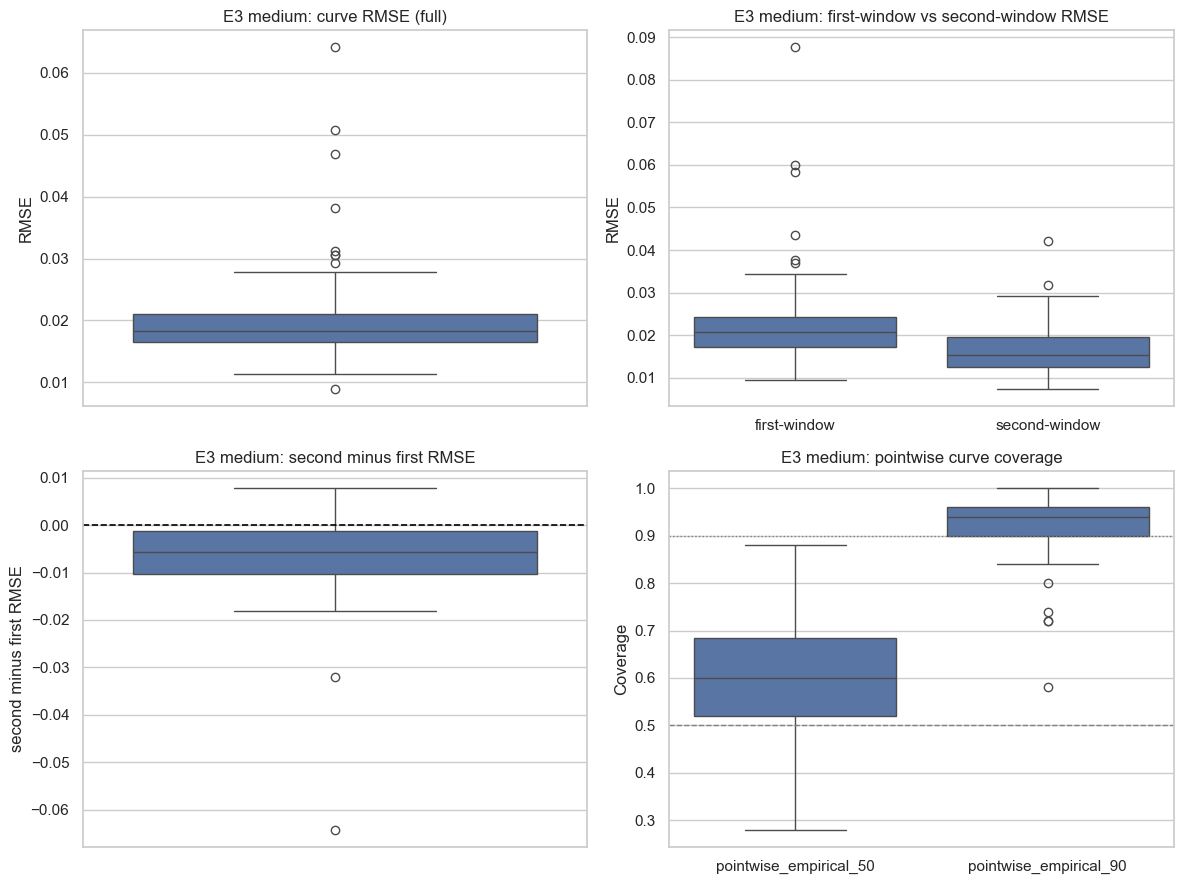

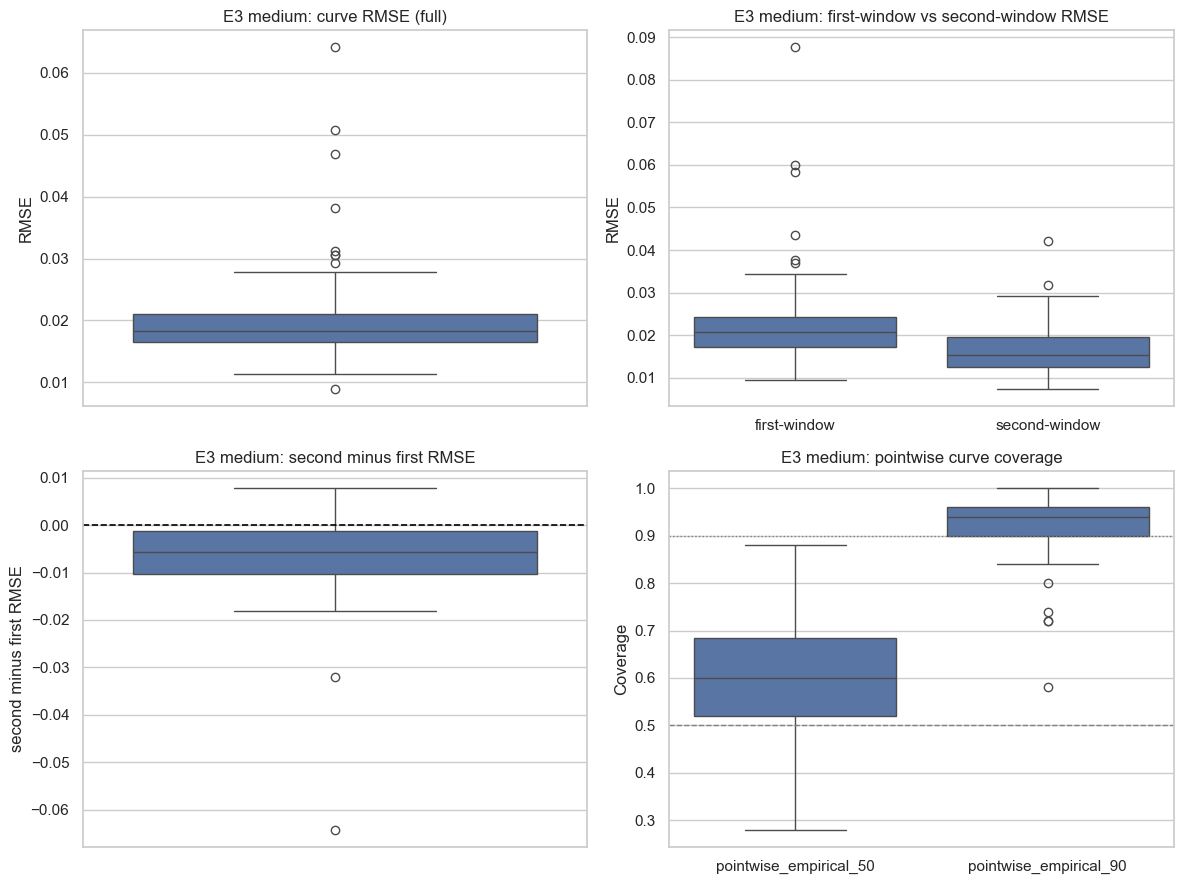

In [27]:
plot_curve_level_ppc_summary(
    curve_outputs_E3["medium"]["case_df"],
    severity_label="medium",
    experiment_label="E3",
    out_dir=str(OUTPUTS_ROOT / "E3" / "curve_level" / "medium"),
    split_mode="fraction",
)


In [28]:
# tau-aligned curve-level PPC for all severities (E3)

display(curve_outputs_E3["strong"]["summary_df"].round(4))
display(curve_outputs_E3["strong"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.5836,0.1508,0.6000,0.3190,0.7800
1,pointwise_empirical_90,0.8724,0.1246,0.9200,0.5980,0.9800
2,curve_bias_full,-0.0045,0.0061,-0.0049,-0.0121,0.0036
3,curve_mae_full,0.0181,0.0111,0.0139,0.0089,0.0421
4,curve_rmse_full,0.0245,0.0153,0.0190,0.0129,0.0508
5,curve_bias_first,-0.0067,0.0167,-0.0050,-0.0364,0.0061
6,curve_mae_first,0.0233,0.0164,0.0178,0.0096,0.0559
7,curve_rmse_first,0.0293,0.0208,0.0221,0.0129,0.0684
8,curve_bias_second,-0.0023,0.0078,-0.0043,-0.0108,0.0149
9,curve_mae_second,0.0128,0.0074,0.0110,0.0060,0.0294


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,second_minus_first_mae,split_mode,split_idx,true_beta,true_gamma,true_R0,rho0,tau,eta,severity
0,0,0.72,0.92,-0.0063,0.0125,0.0175,-0.0090,0.0161,0.0217,-0.0035,...,-0.0072,fraction,25,0.4567,0.4127,1.1065,1.0,10,0.4120,strong
1,1,0.64,0.94,-0.0094,0.0135,0.0180,-0.0098,0.0132,0.0173,-0.0090,...,0.0005,fraction,25,0.1830,0.1452,1.2602,1.0,22,0.3377,strong
2,2,0.60,0.92,-0.0041,0.0135,0.0175,0.0011,0.0145,0.0177,-0.0093,...,-0.0020,fraction,25,0.8345,0.4220,1.9774,1.0,21,0.3989,strong
3,3,0.60,0.98,-0.0018,0.0122,0.0158,0.0017,0.0160,0.0192,-0.0052,...,-0.0076,fraction,25,0.8501,0.4584,1.8547,1.0,23,0.4248,strong
4,4,0.74,0.96,-0.0059,0.0108,0.0152,-0.0072,0.0139,0.0182,-0.0046,...,-0.0062,fraction,25,0.8313,0.2983,2.7868,1.0,23,0.5100,strong


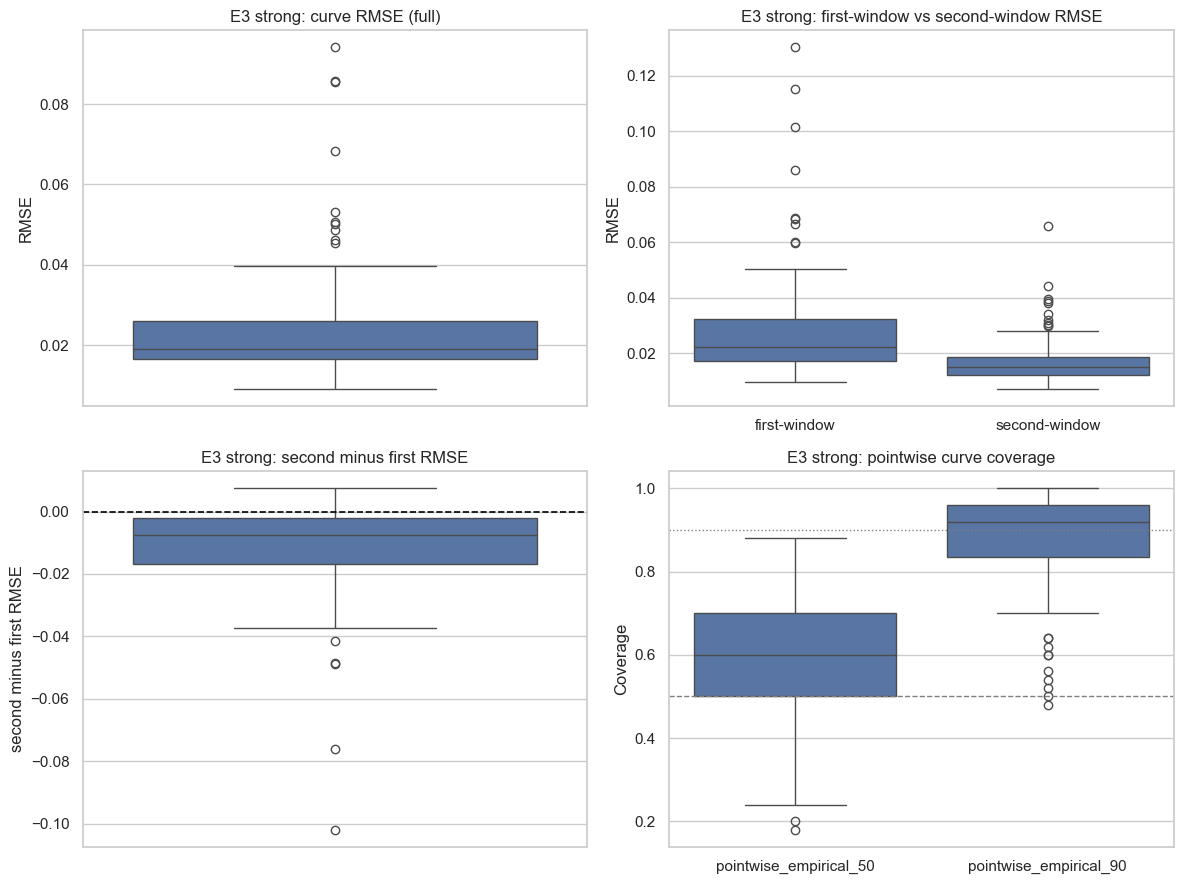

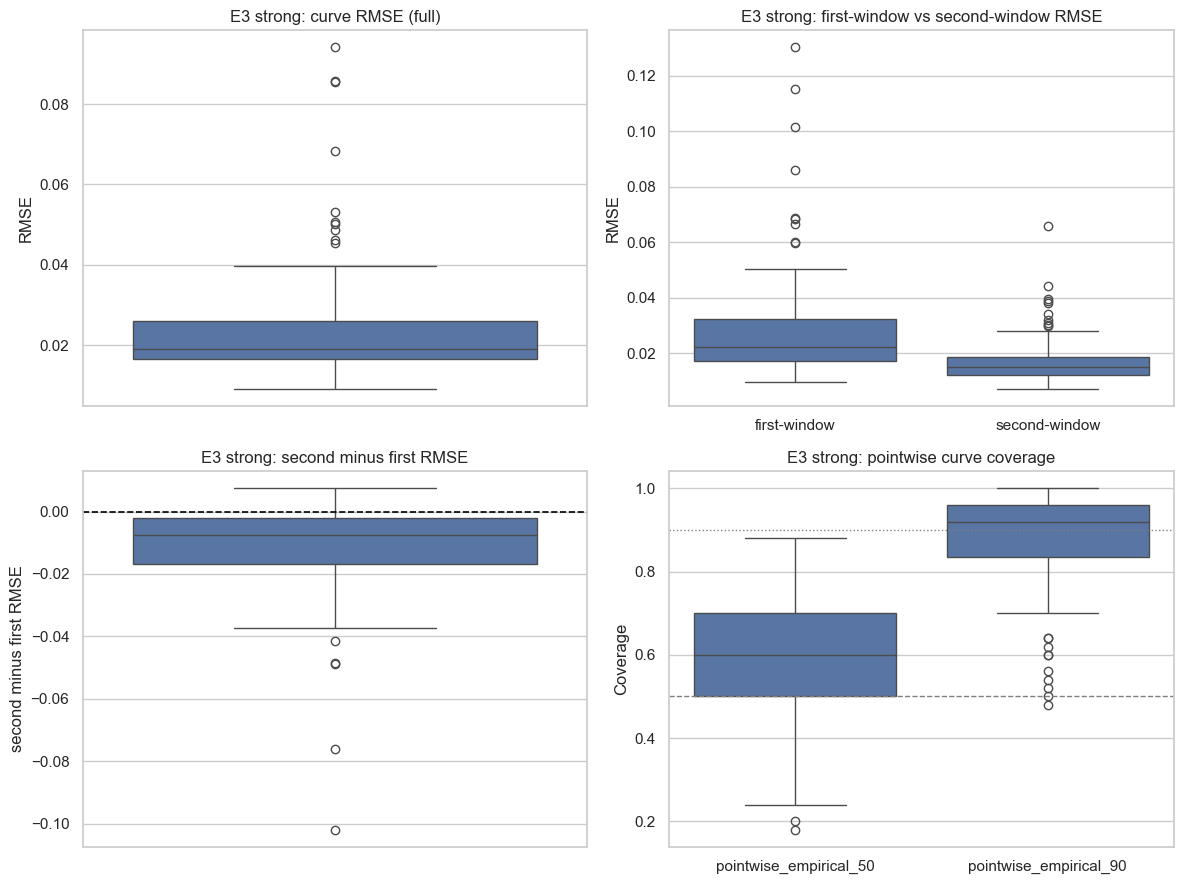

In [29]:
plot_curve_level_ppc_summary(
    curve_outputs_E3["strong"]["case_df"],
    severity_label="strong",
    experiment_label="E3",
    out_dir=str(OUTPUTS_ROOT / "E3" / "curve_level" / "strong"),
    split_mode="fraction",
)


In [30]:
curve_outputs_E3_tau = {}
for sev in ["mild", "medium", "strong"]:
    curve_case_df_tau, curve_summary_df_tau = evaluate_curve_level_ppc_tau_aligned(
        workflow=workflow_E0,
        case_simulator=lambda rng=None, s=sev: simulate_case_E3(rng=rng, severity=s),
        predictive_curve_simulator=simulate_curve,
        n_test=100,
        num_posterior_samples=1000,
        n_ppc_draws=100,
        seed=2032,
    )
    curve_outputs_E3_tau[sev] = {
        "case_df": curve_case_df_tau,
        "summary_df": curve_summary_df_tau,
    }
    out_dir = OUTPUTS_ROOT / "E3" / "curve_level_tau" / sev
    out_dir.mkdir(parents=True, exist_ok=True)
    curve_case_df_tau.to_csv(out_dir / f"E3_curve_case_level_tau_aligned_{sev}.csv", index=False)
    curve_summary_df_tau.to_csv(out_dir / f"E3_curve_summary_tau_aligned_{sev}.csv", index=False)


In [31]:
display(curve_outputs_E3_tau["mild"]["summary_df"].round(4))
display(curve_outputs_E3_tau["mild"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6236,0.1041,0.6200,0.4790,0.8010
1,pointwise_empirical_90,0.9360,0.0365,0.9400,0.8600,1.0000
2,curve_bias_full,-0.0045,0.0037,-0.0045,-0.0105,-0.0006
3,curve_mae_full,0.0142,0.0033,0.0142,0.0084,0.0190
4,curve_rmse_full,0.0185,0.0037,0.0183,0.0120,0.0239
5,curve_bias_first,-0.0054,0.0050,-0.0048,-0.0148,0.0014
6,curve_mae_first,0.0150,0.0039,0.0146,0.0086,0.0214
7,curve_rmse_first,0.0189,0.0045,0.0186,0.0117,0.0263
8,curve_bias_second,-0.0040,0.0061,-0.0046,-0.0130,0.0067
9,curve_mae_second,0.0136,0.0046,0.0135,0.0072,0.0215


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,second_minus_first_mae,split_mode,split_idx,true_beta,true_gamma,true_R0,rho0,tau,eta,severity
0,0,0.56,0.90,-0.0031,0.0158,0.0205,0.0011,0.0146,0.0192,-0.0051,...,0.0017,tau,16,0.5651,0.3255,1.7359,1.0,16,0.9988,mild
1,1,0.70,0.94,-0.0074,0.0109,0.0152,-0.0067,0.0121,0.0154,-0.0080,...,-0.0023,tau,23,0.5389,0.4774,1.1290,1.0,23,0.9215,mild
2,2,0.46,0.94,-0.0089,0.0180,0.0217,-0.0053,0.0145,0.0177,-0.0122,...,0.0067,tau,24,0.3751,0.2689,1.3948,1.0,24,0.9952,mild
3,3,0.72,0.94,-0.0084,0.0127,0.0182,-0.0088,0.0122,0.0176,-0.0082,...,0.0007,tau,12,0.1770,0.1994,0.8880,1.0,12,0.9211,mild
4,4,0.68,0.90,-0.0029,0.0124,0.0170,-0.0028,0.0109,0.0137,-0.0029,...,0.0018,tau,11,0.5963,0.4149,1.4374,1.0,11,0.9457,mild


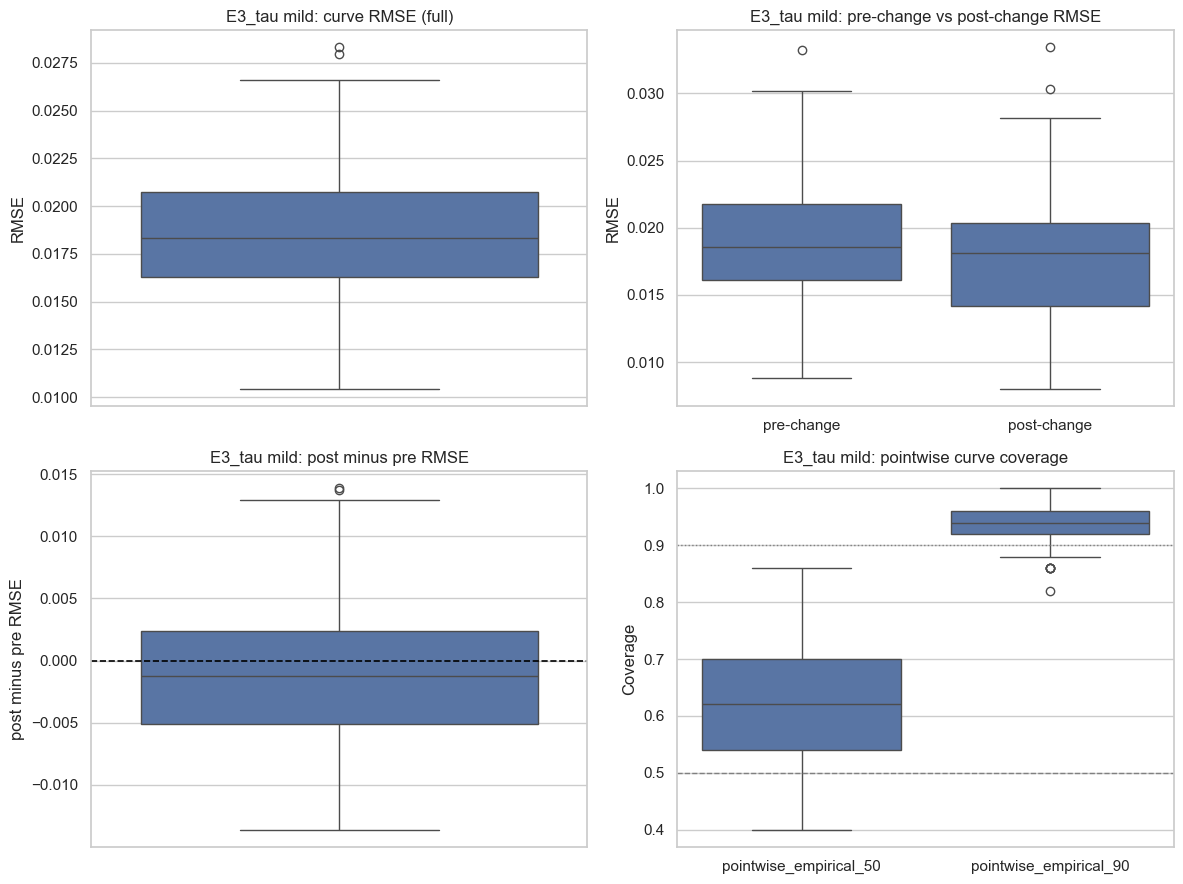

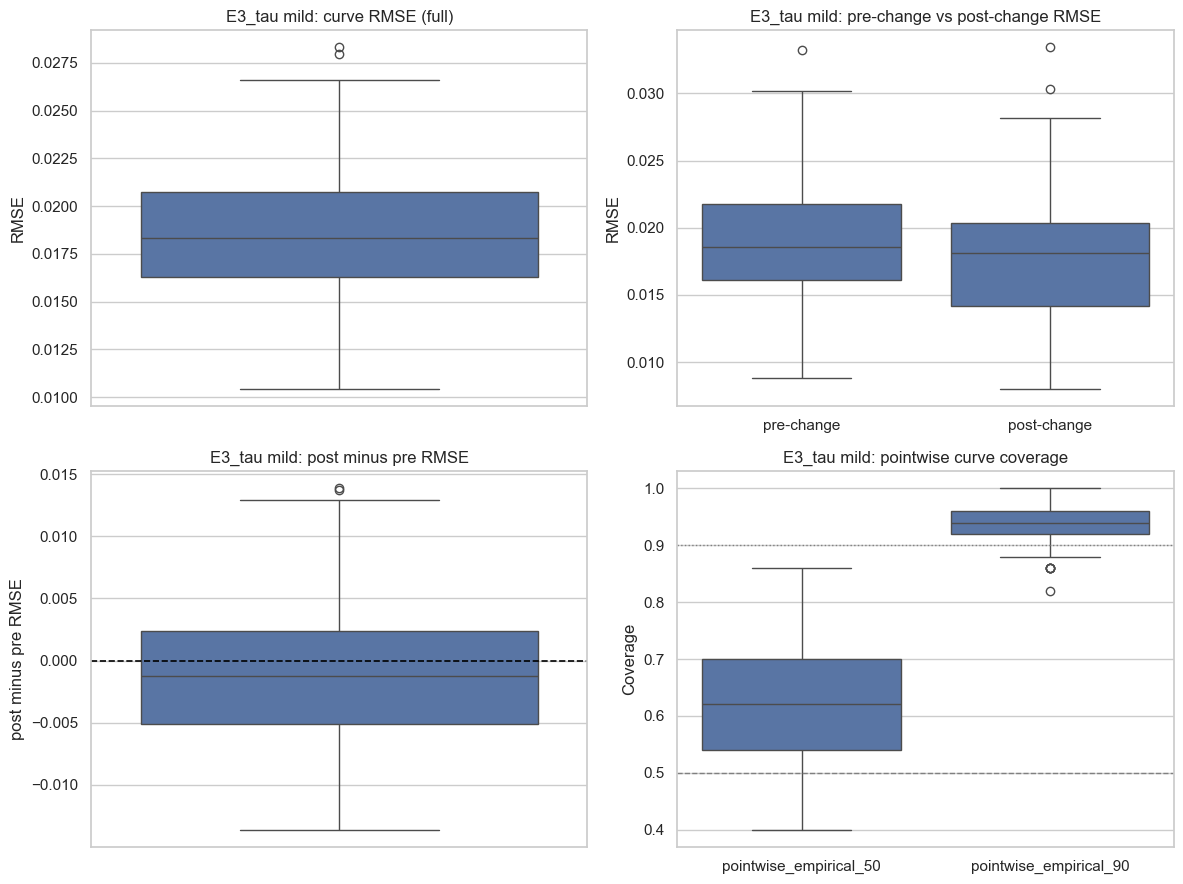

In [32]:
plot_curve_level_ppc_summary(
    curve_outputs_E3_tau["mild"]["case_df"],
    severity_label="mild",
    experiment_label="E3_tau",
    out_dir=str(OUTPUTS_ROOT / "E3" / "curve_level_tau" / "mild"),
    split_mode="tau",
)


In [33]:
display(curve_outputs_E3_tau["medium"]["summary_df"].round(4))
display(curve_outputs_E3_tau["medium"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6052,0.1235,0.6000,0.3990,0.7810
1,pointwise_empirical_90,0.9134,0.0615,0.9200,0.7990,0.9800
2,curve_bias_full,-0.0046,0.0044,-0.0053,-0.0115,0.0018
3,curve_mae_full,0.0153,0.0050,0.0141,0.0084,0.0243
4,curve_rmse_full,0.0201,0.0060,0.0186,0.0119,0.0302
5,curve_bias_first,-0.0083,0.0075,-0.0066,-0.0215,0.0007
6,curve_mae_first,0.0167,0.0061,0.0153,0.0092,0.0270
7,curve_rmse_first,0.0211,0.0074,0.0193,0.0115,0.0335
8,curve_bias_second,-0.0022,0.0080,-0.0040,-0.0112,0.0123
9,curve_mae_second,0.0143,0.0060,0.0131,0.0070,0.0228


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,second_minus_first_mae,split_mode,split_idx,true_beta,true_gamma,true_R0,rho0,tau,eta,severity
0,0,0.54,0.90,-0.0036,0.0155,0.0202,-0.0001,0.0147,0.0188,-0.0053,...,0.0011,tau,16,0.5651,0.3255,1.7359,1.0,16,0.8480,medium
1,1,0.76,0.94,-0.0064,0.0104,0.0145,-0.0061,0.0120,0.0151,-0.0067,...,-0.0029,tau,23,0.5389,0.4774,1.1290,1.0,23,0.7192,medium
2,2,0.50,0.96,-0.0079,0.0178,0.0214,-0.0051,0.0148,0.0179,-0.0104,...,0.0058,tau,24,0.3751,0.2689,1.3948,1.0,24,0.8420,medium
3,3,0.76,0.94,-0.0073,0.0124,0.0176,-0.0081,0.0124,0.0174,-0.0071,...,0.0001,tau,12,0.1770,0.1994,0.8880,1.0,12,0.7185,medium
4,4,0.72,0.92,-0.0027,0.0122,0.0167,-0.0047,0.0116,0.0139,-0.0021,...,0.0008,tau,11,0.5963,0.4149,1.4374,1.0,11,0.7594,medium


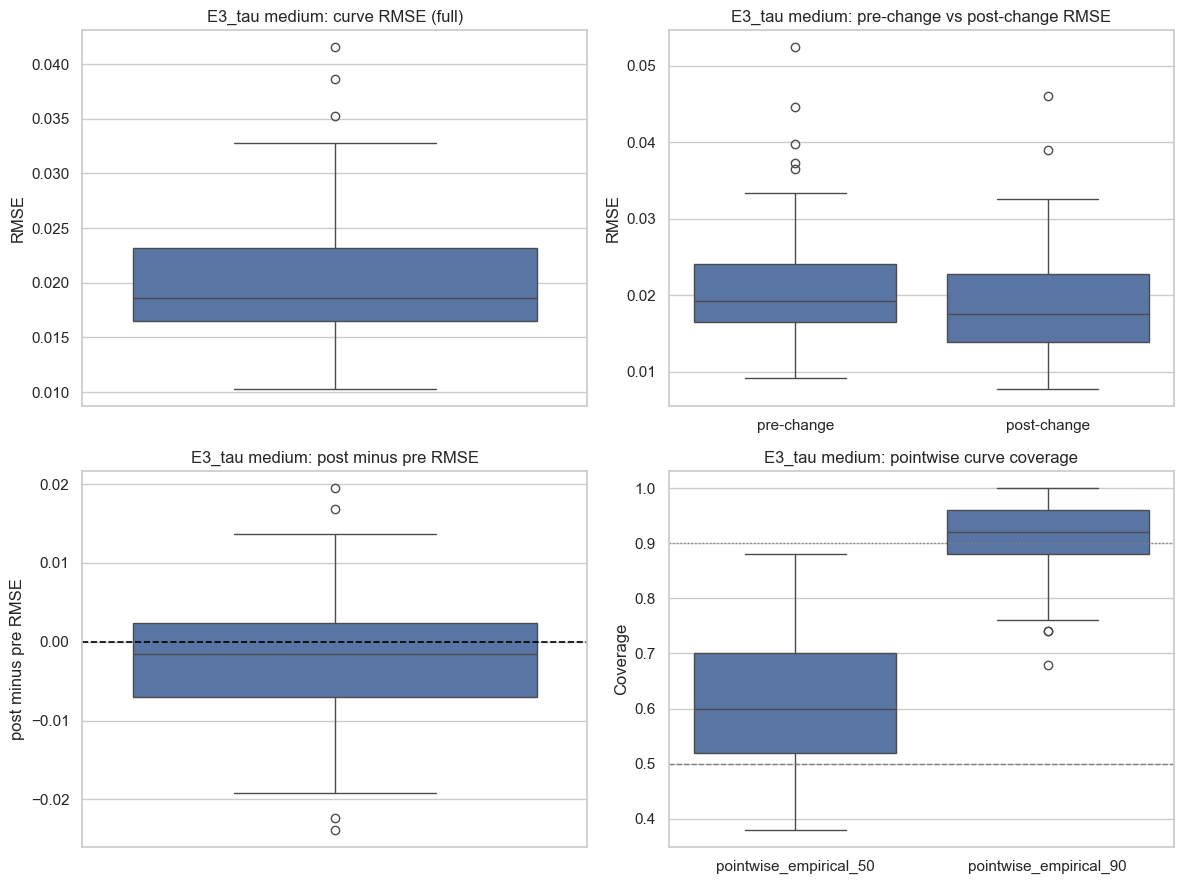

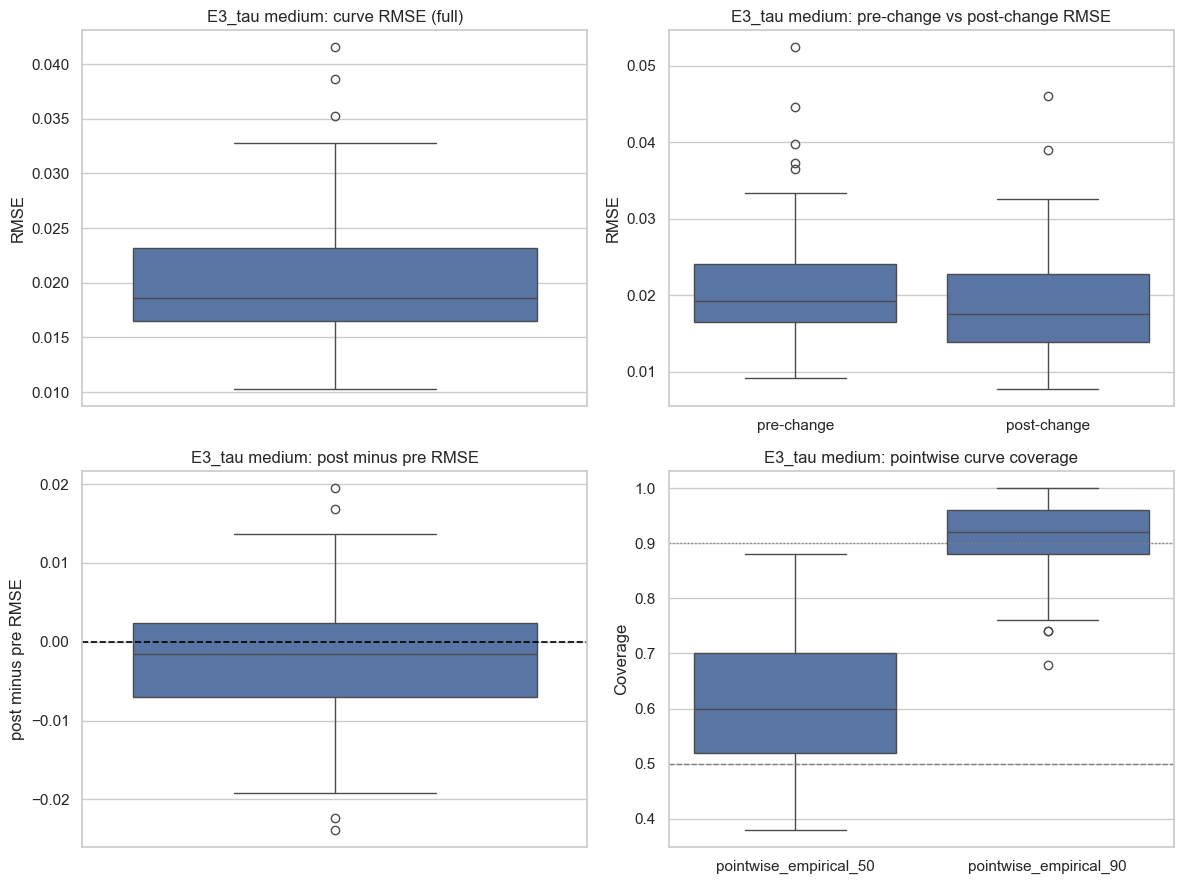

In [34]:
plot_curve_level_ppc_summary(
    curve_outputs_E3_tau["medium"]["case_df"],
    severity_label="medium",
    experiment_label="E3_tau",
    out_dir=str(OUTPUTS_ROOT / "E3" / "curve_level_tau" / "medium"),
    split_mode="tau",
)


In [35]:
# load and combine case-level outputs

display(curve_outputs_E3_tau["strong"]["summary_df"].round(4))
display(curve_outputs_E3_tau["strong"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.5868,0.1445,0.5900,0.3200,0.8000
1,pointwise_empirical_90,0.8754,0.1160,0.9200,0.6400,0.9800
2,curve_bias_full,-0.0051,0.0050,-0.0052,-0.0122,0.0001
3,curve_mae_full,0.0174,0.0087,0.0150,0.0084,0.0358
4,curve_rmse_full,0.0236,0.0118,0.0199,0.0120,0.0485
5,curve_bias_first,-0.0124,0.0128,-0.0083,-0.0389,-0.0008
6,curve_mae_first,0.0205,0.0119,0.0162,0.0089,0.0417
7,curve_rmse_first,0.0261,0.0149,0.0199,0.0115,0.0564
8,curve_bias_second,-0.0001,0.0099,-0.0031,-0.0098,0.0215
9,curve_mae_second,0.0153,0.0083,0.0127,0.0065,0.0317


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,second_minus_first_mae,split_mode,split_idx,true_beta,true_gamma,true_R0,rho0,tau,eta,severity
0,0,0.60,0.90,-0.0039,0.0151,0.0201,-0.0013,0.0144,0.0189,-0.0051,...,0.0010,tau,16,0.5651,0.3255,1.7359,1.0,16,0.5976,strong
1,1,0.80,0.98,-0.0044,0.0098,0.0134,-0.0054,0.0118,0.0147,-0.0036,...,-0.0036,tau,23,0.5389,0.4774,1.1290,1.0,23,0.4430,strong
2,2,0.46,0.94,-0.0095,0.0170,0.0206,-0.0086,0.0150,0.0188,-0.0103,...,0.0038,tau,24,0.3751,0.2689,1.3948,1.0,24,0.5904,strong
3,3,0.78,0.92,-0.0073,0.0119,0.0173,-0.0085,0.0123,0.0177,-0.0069,...,-0.0005,tau,12,0.1770,0.1994,0.8880,1.0,12,0.4422,strong
4,4,0.68,0.94,-0.0038,0.0129,0.0172,-0.0111,0.0151,0.0192,-0.0017,...,-0.0029,tau,11,0.5963,0.4149,1.4374,1.0,11,0.4913,strong


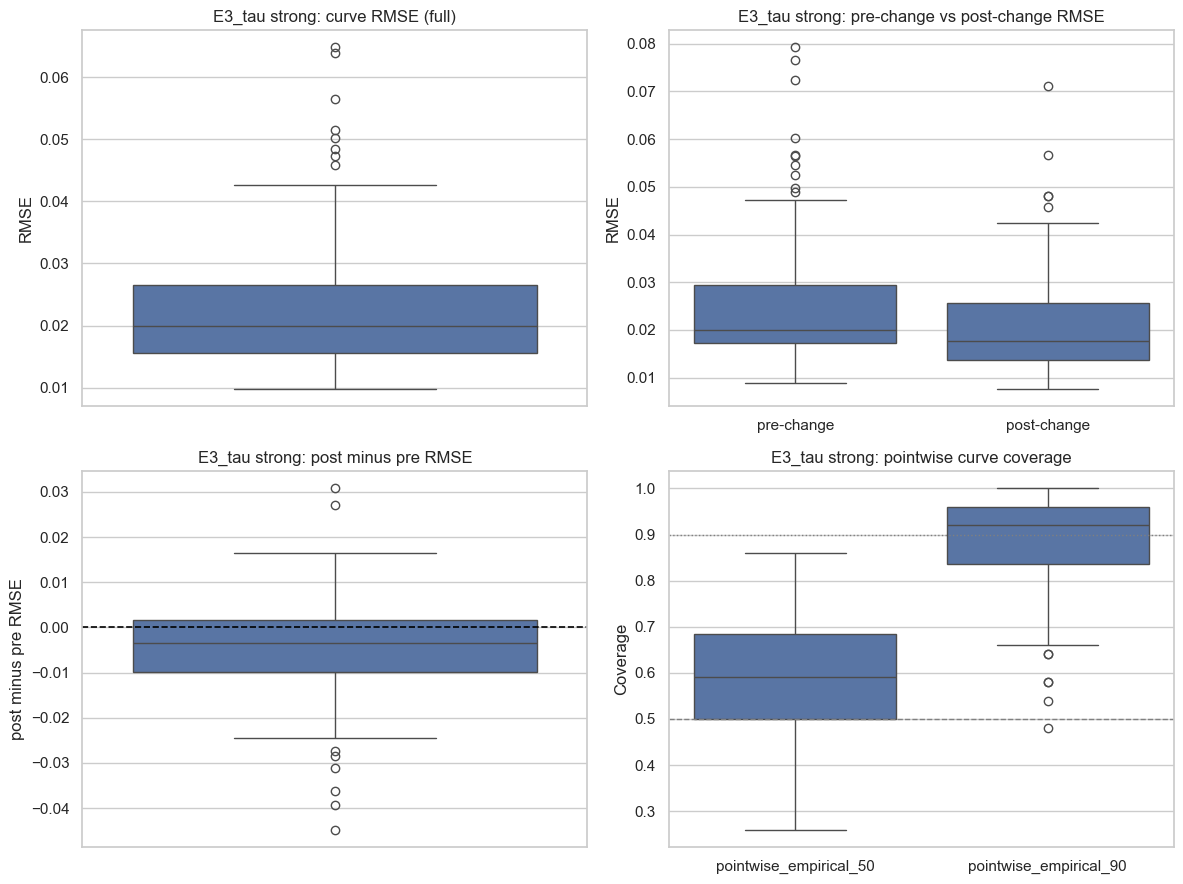

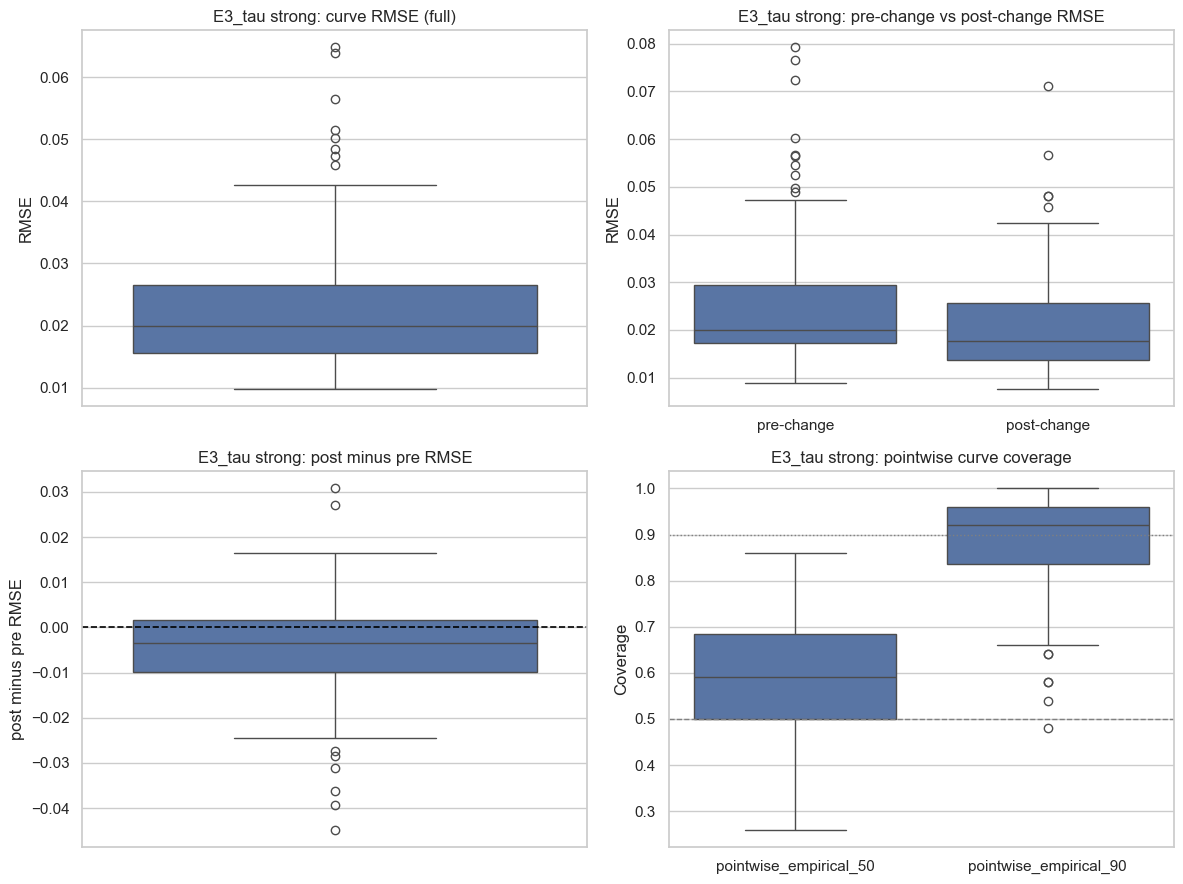

In [36]:
# correlation summaries

plot_curve_level_ppc_summary(
    curve_outputs_E3_tau["strong"]["case_df"],
    severity_label="strong",
    experiment_label="E3_tau",
    out_dir=str(OUTPUTS_ROOT / "E3" / "curve_level_tau" / "strong"),
    split_mode="tau",
)


In [37]:
E3_case_all = pd.concat(
    [severity_outputs_E3["mild"]["case_df"], severity_outputs_E3["medium"]["case_df"], severity_outputs_E3["strong"]["case_df"]],
    axis=0,
    ignore_index=True,
)
E3_case_all["severity"] = pd.Categorical(E3_case_all["severity"], categories=["mild", "medium", "strong"], ordered=True)
caselevel_dir_E3 = OUTPUTS_ROOT / "E3" / "caselevel_analysis"
caselevel_dir_E3.mkdir(parents=True, exist_ok=True)
E3_case_all.to_csv(caselevel_dir_E3 / "E3_case_level_all.csv", index=False)
print("Combined E3 case-level data:")
print(E3_case_all.shape)
display(E3_case_all.head())


Combined E3 case-level data:
(300, 53)


,case_id,true_beta,true_gamma,true_R0,rho0,tau,eta,severity,beta_mean,beta_median,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.448077,0.316651,1.415052,1.0,14,0.997739,mild,0.449942,0.448686,...,0.006202,0.005103,0.005103,0.000026,1.0,1.0,-0.014906,-0.022381,0.022381,0.000501
1,1,0.865699,0.377376,2.293997,1.0,25,0.933624,mild,0.862201,0.866124,...,0.013584,0.012577,0.012577,0.000158,0.0,1.0,-0.086682,-0.089584,0.089584,0.008025
2,2,0.130403,0.316478,0.412045,1.0,13,0.862665,mild,0.206815,0.185790,...,0.004154,0.017977,0.017977,0.000323,0.0,1.0,0.268668,0.246473,0.246473,0.060749
3,3,0.522899,0.184464,2.834688,1.0,24,0.870251,mild,0.529435,0.529301,...,0.013743,0.013565,0.013565,0.000184,0.0,0.0,-0.161610,-0.164032,0.164032,0.026907
4,4,0.258551,0.209109,1.236443,1.0,21,0.911207,mild,0.300203,0.296424,...,0.091669,0.094618,0.094618,0.008953,0.0,1.0,-0.210595,-0.206040,0.206040,0.042453


In [38]:
E3_caselevel_corr_df = build_E3_caselevel_correlation_summary(E3_case_all)
E3_caselevel_corr_df.to_csv(caselevel_dir_E3 / "E3_caselevel_correlation_summary.csv", index=False)
display(E3_caselevel_corr_df.round(4))


,group,x,y,pearson_corr
0,pooled,eta,R0_err_median,0.2600
1,pooled,eta,gamma_err_median,-0.1879
2,pooled,eta,R0_covered90,0.3138
3,pooled,tau,R0_err_median,0.1392
4,pooled,tau,R0_covered90,0.3089
5,pooled,tau,gamma_err_median,-0.2285
6,mild,eta,R0_err_median,0.1158
7,mild,eta,gamma_err_median,0.0331
8,mild,eta,R0_covered90,0.1961
9,mild,tau,R0_err_median,0.0982


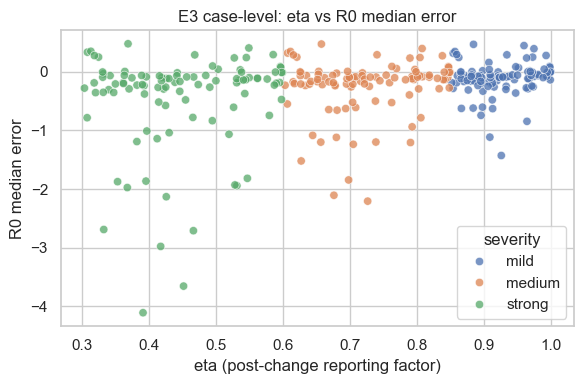

In [39]:
scatter_with_group_colors(
    E3_case_all,
    x="eta",
    y="R0_err_median",
    title="E3 case-level: eta vs R0 median error",
    xlabel="eta (post-change reporting factor)",
    ylabel="R0 median error",
    out_path=str(caselevel_dir_E3 / "E3_eta_vs_R0_err_median.png"),
)


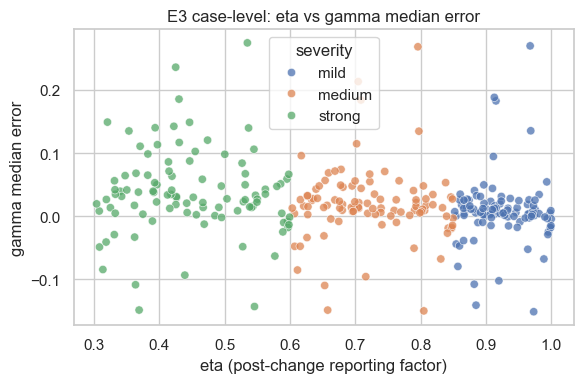

In [40]:
scatter_with_group_colors(
    E3_case_all,
    x="eta",
    y="gamma_err_median",
    title="E3 case-level: eta vs gamma median error",
    xlabel="eta (post-change reporting factor)",
    ylabel="gamma median error",
    out_path=str(caselevel_dir_E3 / "E3_eta_vs_gamma_err_median.png"),
)


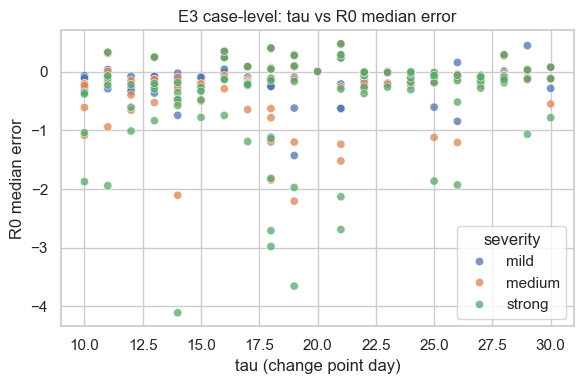

In [41]:
# binned summaries by eta / tau

scatter_with_group_colors(
    E3_case_all,
    x="tau",
    y="R0_err_median",
    title="E3 case-level: tau vs R0 median error",
    xlabel="tau (change point day)",
    ylabel="R0 median error",
    out_path=str(caselevel_dir_E3 / "E3_tau_vs_R0_err_median.png"),
)


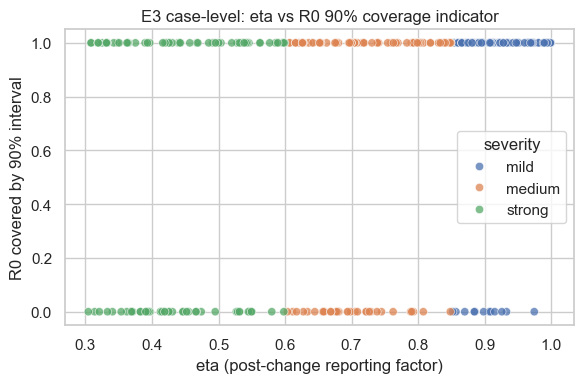

In [42]:
scatter_with_group_colors(
    E3_case_all,
    x="eta",
    y="R0_covered90",
    title="E3 case-level: eta vs R0 90% coverage indicator",
    xlabel="eta (post-change reporting factor)",
    ylabel="R0 covered by 90% interval",
    out_path=str(caselevel_dir_E3 / "E3_eta_vs_R0_covered90.png"),
)


In [43]:
E3_case_binned, eta_bin_summary, tau_bin_summary = build_E3_eta_tau_bin_summaries(E3_case_all)
eta_bin_summary.to_csv(caselevel_dir_E3 / "E3_eta_bin_summary.csv", index=False)
tau_bin_summary.to_csv(caselevel_dir_E3 / "E3_tau_bin_summary.csv", index=False)
print("Eta-bin summary:")
display(eta_bin_summary.round(4))
print("Tau-bin summary:")
display(tau_bin_summary.round(4))


Eta-bin summary:


,eta_bin,n_cases,eta_mean,R0_err_median_mean,gamma_err_median_mean,R0_covered90_rate,gamma_covered90_rate
0,"(0.303, 0.532]",75,0.4097,-0.5472,0.0395,0.5200,0.4400
1,"(0.532, 0.712]",75,0.6299,-0.2923,0.0253,0.6400,0.5333
2,"(0.712, 0.886]",75,0.8148,-0.1497,0.0075,0.7733,0.6933
3,"(0.886, 1.0]",75,0.9429,-0.1307,0.0130,0.9067,0.8400


Tau-bin summary:


,tau_bin,n_cases,tau_mean,R0_err_median_mean,gamma_err_median_mean,R0_covered90_rate,gamma_covered90_rate
0,"(9.999, 15.0]",84,12.4643,-0.3674,0.0458,0.5238,0.4405
1,"(15.0, 19.0]",69,17.5652,-0.3997,0.0252,0.6377,0.5362
2,"(19.0, 25.0]",78,22.9231,-0.1958,-0.0007,0.8205,0.7564
3,"(25.0, 30.0]",69,27.7826,-0.1491,0.0126,0.8841,0.7971


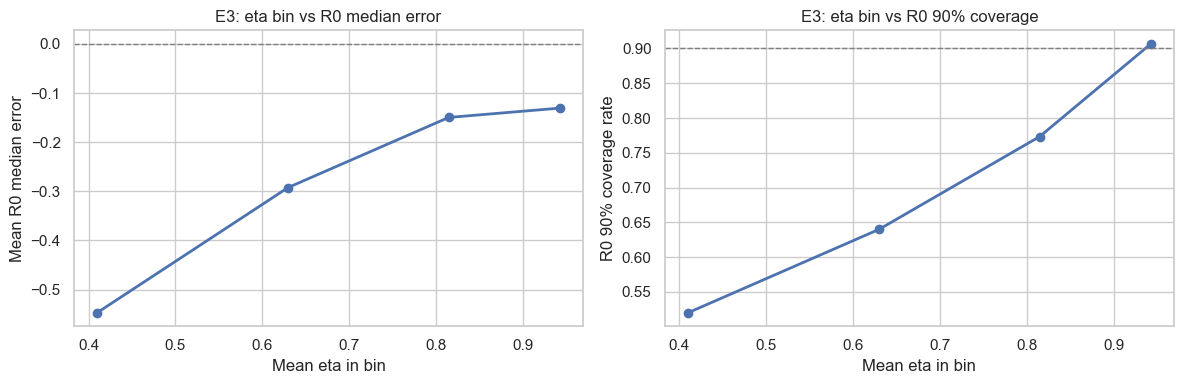

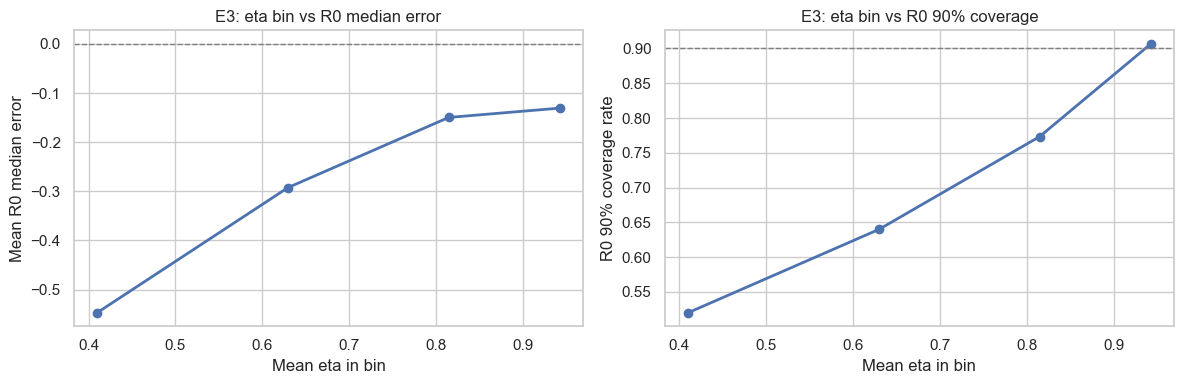

In [44]:
# create truth-region bins

plot_E3_eta_bin_panels(
    eta_bin_summary,
    out_path=str(caselevel_dir_E3 / "E3_eta_bin_panels.png"),
)


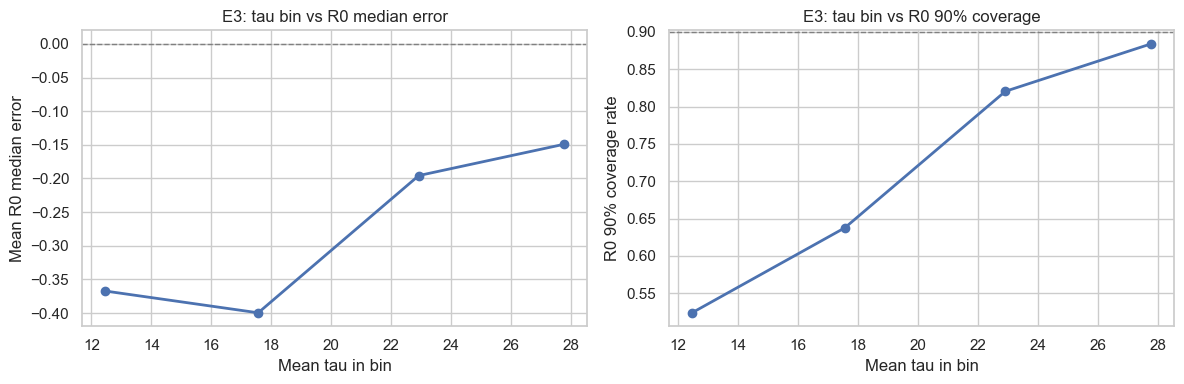

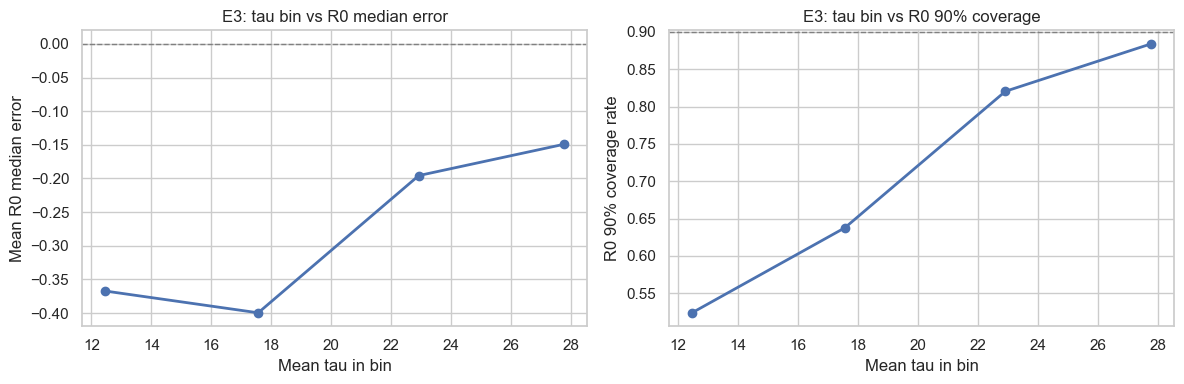

In [45]:
# summarize by truth-region groups

plot_E3_tau_bin_panels(
    tau_bin_summary,
    out_path=str(caselevel_dir_E3 / "E3_tau_bin_panels.png"),
)


In [46]:
truth_tables_E3 = build_E3_truth_region_tables(E3_case_all)
truth_dir_E3 = OUTPUTS_ROOT / "E3" / "truth_region_analysis"
truth_dir_E3.mkdir(parents=True, exist_ok=True)
truth_tables_E3["truth_df"].to_csv(truth_dir_E3 / "E3_truth_df.csv", index=False)
truth_tables_E3["gamma_group_summary"].to_csv(truth_dir_E3 / "E3_summary_by_true_gamma_group.csv", index=False)
truth_tables_E3["R0_group_summary"].to_csv(truth_dir_E3 / "E3_summary_by_true_R0_group.csv", index=False)
truth_tables_E3["beta_group_summary"].to_csv(truth_dir_E3 / "E3_summary_by_true_beta_group.csv", index=False)
truth_tables_E3["severity_gamma_group_summary"].to_csv(truth_dir_E3 / "E3_severity_x_true_gamma_group.csv", index=False)
truth_tables_E3["severity_R0_group_summary"].to_csv(truth_dir_E3 / "E3_severity_x_true_R0_group.csv", index=False)
truth_tables_E3["pivot_R0_cov_by_gamma"].to_csv(truth_dir_E3 / "E3_pivot_R0_cov_by_gamma.csv")
truth_tables_E3["pivot_gamma_cov_by_gamma"].to_csv(truth_dir_E3 / "E3_pivot_gamma_cov_by_gamma.csv")
truth_tables_E3["pivot_R0_cov_by_R0"].to_csv(truth_dir_E3 / "E3_pivot_R0_cov_by_R0.csv")
display(truth_tables_E3["truth_df"][["case_id", "severity", "true_beta", "true_gamma", "true_R0", "true_beta_group", "true_gamma_group", "true_R0_group"]].head())


,case_id,severity,true_beta,true_gamma,true_R0,true_beta_group,true_gamma_group,true_R0_group
0,0,mild,0.448077,0.316651,1.415052,low,mid,low
1,1,mild,0.865699,0.377376,2.293997,high,high,mid
2,2,mild,0.130403,0.316478,0.412045,low,mid,low
3,3,mild,0.522899,0.184464,2.834688,mid,low,mid
4,4,mild,0.258551,0.209109,1.236443,low,mid,low


In [47]:
display(truth_tables_E3["gamma_group_summary"].round(4))
display(truth_tables_E3["R0_group_summary"].round(4))
display(truth_tables_E3["beta_group_summary"].round(4))


,true_gamma_group,n_cases,true_beta_mean,true_gamma_mean,true_R0_mean,beta_err_median_mean,gamma_err_median_mean,R0_err_median_mean,beta_covered90_rate,gamma_covered90_rate,R0_covered90_rate
0,low,102,0.5659,0.1227,5.5481,0.0265,0.0360,-0.7482,0.6863,0.3431,0.4706
1,mid,99,0.5572,0.2909,1.9806,0.0396,0.0465,-0.0846,0.8283,0.6869,0.7778
2,high,99,0.5980,0.4261,1.4183,-0.0146,-0.0190,0.0070,0.9697,0.8586,0.8889


,true_R0_group,n_cases,true_beta_mean,true_gamma_mean,true_R0_mean,beta_err_median_mean,gamma_err_median_mean,R0_err_median_mean,beta_covered90_rate,gamma_covered90_rate,R0_covered90_rate
0,low,102,0.3373,0.3560,0.9727,0.0067,0.0156,0.0117,0.8922,0.8627,0.9020
1,mid,99,0.6723,0.3251,2.1258,0.0267,0.0284,-0.1188,0.7677,0.5556,0.6768
2,high,99,0.7185,0.1516,5.9872,0.0186,0.0202,-0.7417,0.8182,0.4545,0.5455


,true_beta_group,n_cases,true_beta_mean,true_gamma_mean,true_R0_mean,beta_err_median_mean,gamma_err_median_mean,R0_err_median_mean,beta_covered90_rate,gamma_covered90_rate,R0_covered90_rate
0,low,102,0.2801,0.2770,1.4898,0.0284,0.0262,-0.0793,0.7843,0.6961,0.7843
1,mid,99,0.5917,0.2481,3.7549,0.0052,0.0216,-0.5205,0.7879,0.4848,0.5253
2,high,99,0.8580,0.3099,3.8252,0.0179,0.0160,-0.2462,0.9091,0.6970,0.8182


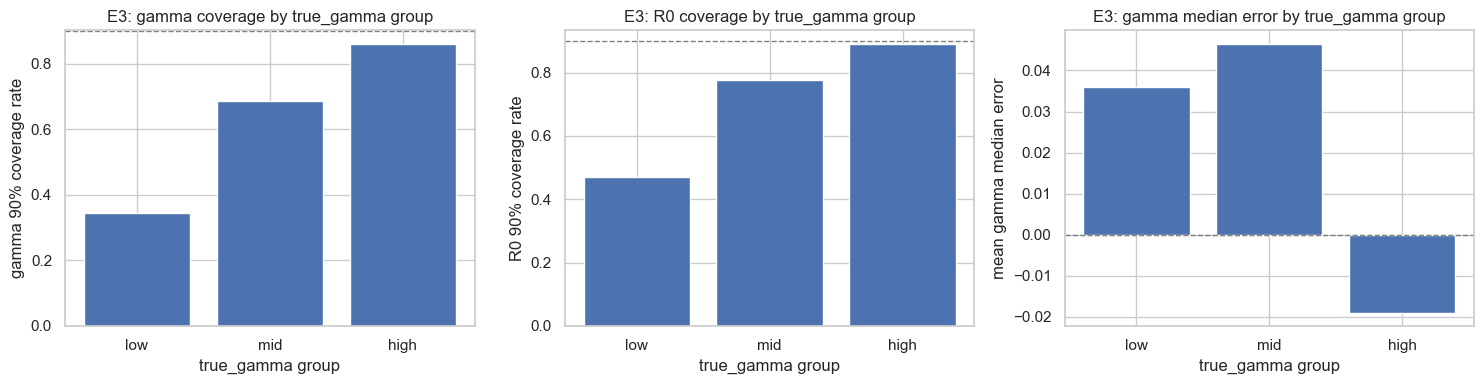

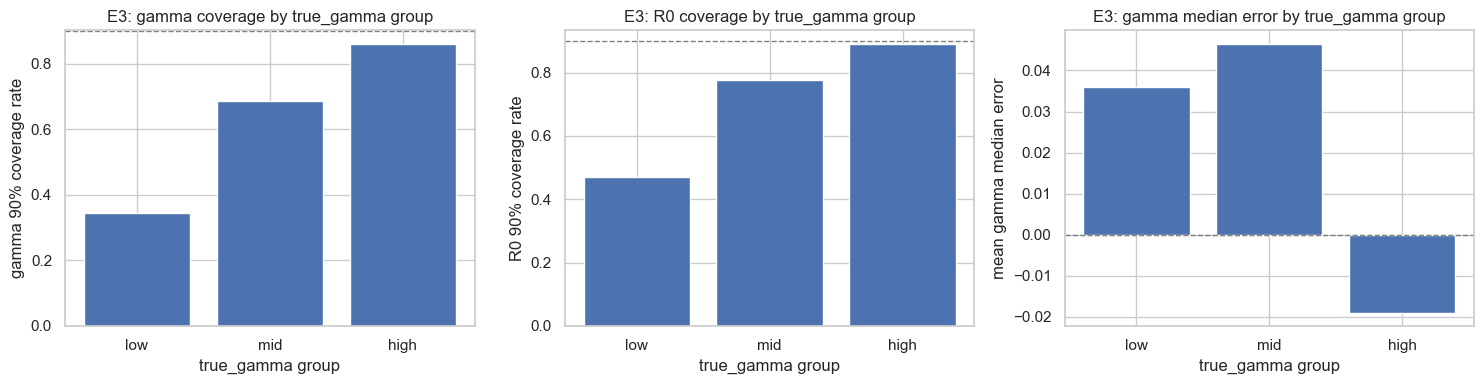

In [48]:
plot_E3_true_gamma_group_panels(
    truth_tables_E3["gamma_group_summary"],
    out_path=str(truth_dir_E3 / "E3_true_gamma_group_panels.png"),
)


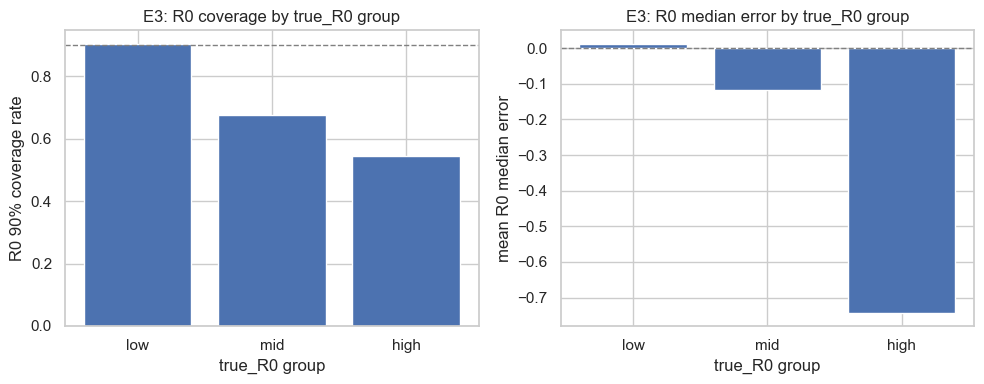

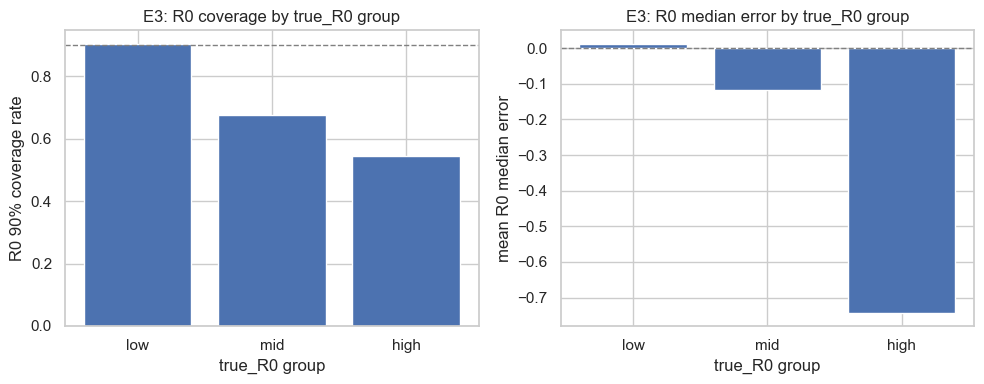

In [49]:
# severity x truth-region summaries

plot_E3_true_R0_group_panels(
    truth_tables_E3["R0_group_summary"],
    out_path=str(truth_dir_E3 / "E3_true_R0_group_panels.png"),
)


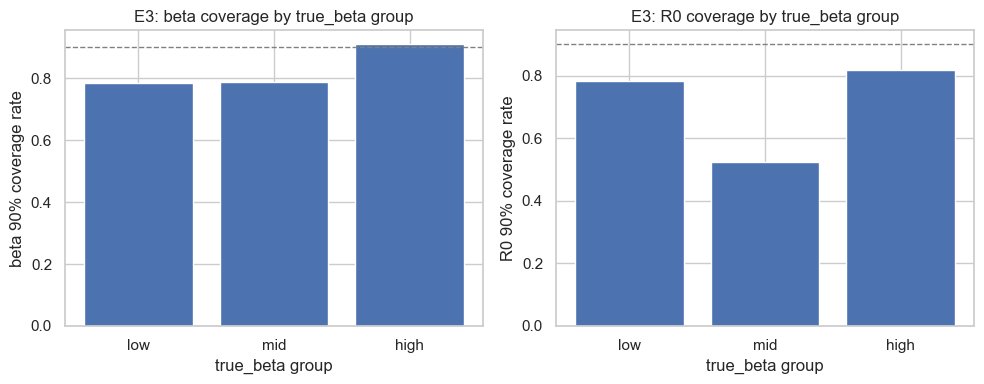

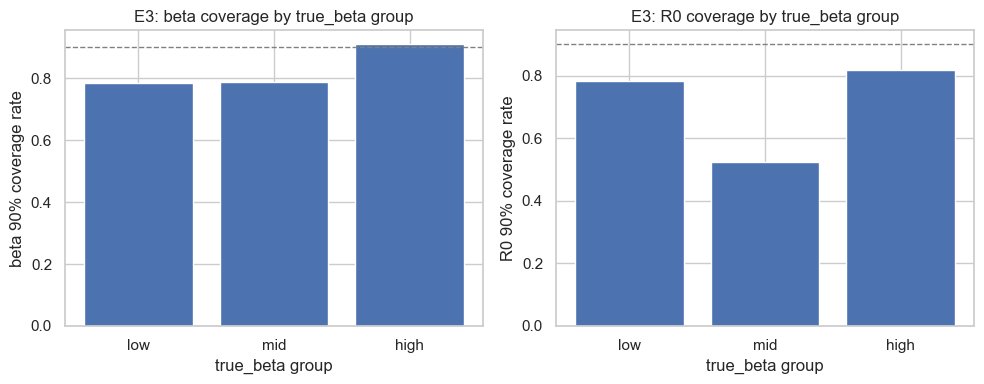

In [50]:
# Pivot tables for quick reading

plot_E3_true_beta_group_panels(
    truth_tables_E3["beta_group_summary"],
    out_path=str(truth_dir_E3 / "E3_true_beta_group_panels.png"),
)


In [51]:
display(truth_tables_E3["severity_gamma_group_summary"].round(4))
display(truth_tables_E3["severity_R0_group_summary"].round(4))


,severity,true_gamma_group,n_cases,gamma_err_median_mean,R0_err_median_mean,gamma_covered90_rate,R0_covered90_rate
0,mild,low,34,0.0178,-0.3134,0.7647,0.7941
1,mild,mid,33,0.0303,-0.0431,0.8485,0.9394
2,mild,high,33,-0.0245,0.0192,0.8788,0.9091
3,medium,low,34,0.0313,-0.6898,0.2059,0.4118
4,medium,mid,33,0.0447,-0.0805,0.6667,0.7576
5,medium,high,33,-0.0193,0.0083,0.8485,0.8788
6,strong,low,34,0.0589,-1.2413,0.0588,0.2059
7,strong,mid,33,0.0645,-0.1302,0.5455,0.6364
8,strong,high,33,-0.0130,-0.0063,0.8485,0.8788


,severity,true_R0_group,n_cases,gamma_err_median_mean,R0_err_median_mean,gamma_covered90_rate,R0_covered90_rate
0,mild,low,34,0.0092,0.0293,0.8824,0.9118
1,mild,mid,33,0.0084,-0.0571,0.7576,0.8788
2,mild,high,33,0.0062,-0.3200,0.8485,0.8485
3,medium,low,34,0.0148,0.0145,0.8824,0.9118
4,medium,mid,33,0.0256,-0.1143,0.5152,0.6667
5,medium,high,33,0.0167,-0.6835,0.3030,0.4545
6,strong,low,34,0.0227,-0.0086,0.8235,0.8824
7,strong,mid,33,0.0511,-0.1849,0.3939,0.4848
8,strong,high,33,0.0377,-1.2217,0.2121,0.3333


In [52]:
print("Pivot: R0 coverage by severity x true_gamma_group")
display(truth_tables_E3["pivot_R0_cov_by_gamma"].round(4))
print("Pivot: gamma coverage by severity x true_gamma_group")
display(truth_tables_E3["pivot_gamma_cov_by_gamma"].round(4))
print("Pivot: R0 coverage by severity x true_R0_group")
display(truth_tables_E3["pivot_R0_cov_by_R0"].round(4))


Pivot: R0 coverage by severity x true_gamma_group


true_gamma_group,low,mid,high
severity,,,
mild,0.7941,0.9394,0.9091
medium,0.4118,0.7576,0.8788
strong,0.2059,0.6364,0.8788


Pivot: gamma coverage by severity x true_gamma_group


true_gamma_group,low,mid,high
severity,,,
mild,0.7647,0.8485,0.8788
medium,0.2059,0.6667,0.8485
strong,0.0588,0.5455,0.8485


Pivot: R0 coverage by severity x true_R0_group


true_R0_group,low,mid,high
severity,,,
mild,0.9118,0.8788,0.8485
medium,0.9118,0.6667,0.4545
strong,0.8824,0.4848,0.3333
